# MUSIC GENRE CLASSIFICATION

## 1. İlk Adımlar - Kütüphane Import Etme ve Dizin Tanımlama

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
import time
import librosa
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

sys.path.append('/content/drive/MyDrive/MusicGenreClassification/src')

In [3]:
from config import *
from data_loader import collect_audio_files
from feature_extraction import extract_basic_features, extract_features_from_metadata
from preprocessing import encode_labels, scale_features
from split_utils import create_train_val_test_split
from train import train_model
from evaluate import evaluate_model, collect_all_results
from visualize import *

In [4]:
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

print("BASE_DIR:", BASE_DIR)
print("SRC_DIR:", SRC_DIR)

BASE_DIR: /content/drive/MyDrive/MusicGenreClassification
SRC_DIR: /content/drive/MyDrive/MusicGenreClassification/src


## 2. Veri Yükleme ve Analizi

In [5]:
GTZAN_GENRES_DIR = Path(f"{RAW_DATA_DIR}/genres_original")

if GTZAN_GENRES_DIR.exists():
    genre_folders = sorted([p.name for p in GTZAN_GENRES_DIR.iterdir() if p.is_dir()])
    print("Bulunan GZTAN genre klasörleri:")
    for g in genre_folders:
        print("-", g)

Bulunan GZTAN genre klasörleri:
- blues
- classical
- country
- disco
- hiphop
- jazz
- metal
- pop
- reggae
- rock


In [6]:
file_counts = OrderedDict()

for genre_dir in sorted(GTZAN_GENRES_DIR.iterdir()):
    if genre_dir.is_dir():
        wav_files = list(genre_dir.glob("*.wav"))
        file_counts[genre_dir.name] = len(wav_files)

file_counts

for genre, count in file_counts.items():
    print(f"{genre}: {count}")

blues: 100
classical: 100
country: 100
disco: 100
hiphop: 100
jazz: 100
metal: 100
pop: 100
reggae: 100
rock: 100


In [7]:
total_files = sum(file_counts.values())
print("Toplam .wav dosyası:", total_files)

Toplam .wav dosyası: 1000


In [8]:
df_metadata = collect_audio_files(GTZAN_GENRES_DIR)
print(df_metadata.shape)
df_metadata.head()

(1000, 3)


,file_path,genre,file_name
0,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00000.wav
1,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00001.wav
2,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00002.wav
3,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00003.wav
4,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00004.wav


In [9]:
df_metadata.tail()

,file_path,genre,file_name
995,/content/drive/MyDrive/MusicGenreClassificatio...,rock,rock.00095.wav
996,/content/drive/MyDrive/MusicGenreClassificatio...,rock,rock.00096.wav
997,/content/drive/MyDrive/MusicGenreClassificatio...,rock,rock.00097.wav
998,/content/drive/MyDrive/MusicGenreClassificatio...,rock,rock.00098.wav
999,/content/drive/MyDrive/MusicGenreClassificatio...,rock,rock.00099.wav


In [10]:
print("Satır sayısı:", len(df_metadata))
print("Kolonlar:", df_metadata.columns.tolist())

Satır sayısı: 1000
Kolonlar: ['file_path', 'genre', 'file_name']


In [11]:
df_metadata.isnull().sum().to_frame(name="missing_values")

,missing_values
file_path,0
genre,0
file_name,0


In [12]:
print("Tekrarlı satır sayısı:", df_metadata.duplicated().sum())

Tekrarlı satır sayısı: 0


In [13]:
print("Etiket dağılımı:\n")
class_counts = df_metadata["genre"].value_counts().sort_index()
print(class_counts)

Etiket dağılımı:

genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


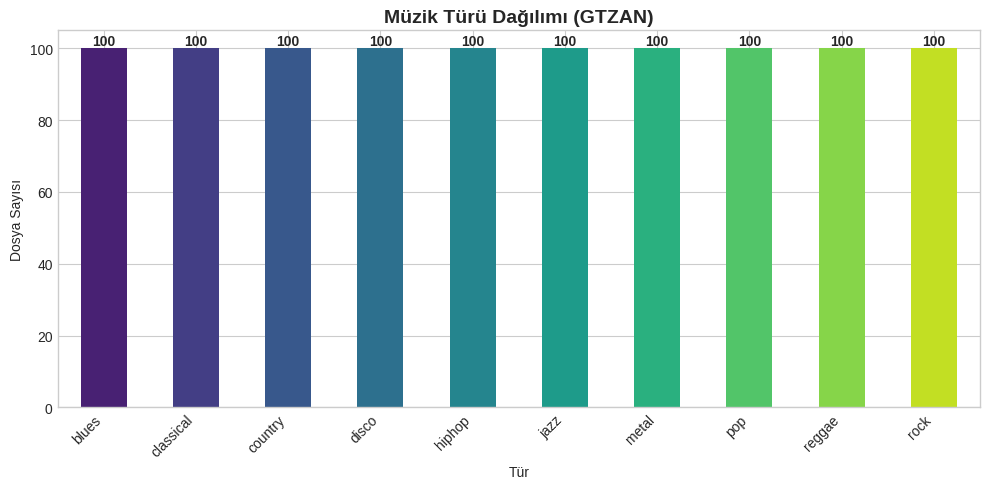

In [14]:
plot_class_distribution(df_metadata, label_col="genre")

In [15]:
sample_file = df_metadata.iloc[0]["file_path"]
y, sr = librosa.load(sample_file, sr=SAMPLE_RATE)

print("Örnek dosya:", sample_file)
print("Sample rate:", sr) #bir ses sinyalinin saniyede kaç kez ölçüldüğü/örneklendiği
print("Sinyal uzunluğu:", len(y)) #22050 × 30 = 661500
print("Süre (sn):", len(y) / sr)

Örnek dosya: /content/drive/MyDrive/MusicGenreClassification/data/raw/genres_original/blues/blues.00000.wav
Sample rate: 22050
Sinyal uzunluğu: 661794
Süre (sn): 30.013333333333332


In [16]:
metadata_path = BASE_DIR / "data" / "interim" / "metadata.csv"
df_metadata.to_csv(metadata_path, index=False)

print("Metadata kaydedildi:", metadata_path)

Metadata kaydedildi: /content/drive/MyDrive/MusicGenreClassification/data/interim/metadata.csv


In [17]:
print("Metadata shape:", df_metadata.shape)
df_metadata.head()

Metadata shape: (1000, 3)


,file_path,genre,file_name
0,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00000.wav
1,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00001.wav
2,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00002.wav
3,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00003.wav
4,/content/drive/MyDrive/MusicGenreClassificatio...,blues,blues.00004.wav


## 3. Özellik Çıkarımı (Feature Extraction)

In [18]:
sample_file = df_metadata.iloc[0]["file_path"]

sample_features = extract_basic_features(
    file_path= sample_file,
    sample_rate= SAMPLE_RATE,
    n_mfcc=13
)

print("Örnek dosya:", sample_file)
print("Çıkarılan feature sayısı:", len(sample_features), "\n")
sample_features

Örnek dosya: /content/drive/MyDrive/MusicGenreClassification/data/raw/genres_original/blues/blues.00000.wav
Çıkarılan feature sayısı: 37 



{'zcr_mean': 0.08304482066898686,
 'zcr_std': 0.027693783681433826,
 'spectral_centroid_mean': 1784.1226412753101,
 'spectral_centroid_std': 360.20200501843135,
 'spectral_rolloff_mean': 3805.7230301080335,
 'spectral_rolloff_std': 949.3434134740136,
 'chroma_mean': 0.35012850165367126,
 'chroma_std': 0.2979457378387451,
 'rms_mean': 0.1301843225955963,
 'rms_std': 0.05318251624703407,
 'tempo': 123.046875,
 'mfcc_1_mean': -113.59882354736328,
 'mfcc_1_std': 50.68894958496094,
 'mfcc_2_mean': 121.57067108154297,
 'mfcc_2_std': 17.200206756591797,
 'mfcc_3_mean': -19.162261962890625,
 'mfcc_3_std': 15.348760604858398,
 'mfcc_4_mean': 42.36394119262695,
 'mfcc_4_std': 12.28978157043457,
 'mfcc_5_mean': -6.3622660636901855,
 'mfcc_5_std': 12.961207389831543,
 'mfcc_6_mean': 18.621931076049805,
 'mfcc_6_std': 9.443115234375,
 'mfcc_7_mean': -13.69973373413086,
 'mfcc_7_std': 8.2221097946167,
 'mfcc_8_mean': 15.339801788330078,
 'mfcc_8_std': 8.306714057922363,
 'mfcc_9_mean': -12.274305343

In [19]:
df_features, error_files = extract_features_from_metadata(
    df_metadata=df_metadata,
    sample_rate=SAMPLE_RATE,
    n_mfcc=13,
    verbose=True
)

[INFO] 50/1000 dosya işlendi.
[INFO] 100/1000 dosya işlendi.
[INFO] 150/1000 dosya işlendi.
[INFO] 200/1000 dosya işlendi.
[INFO] 250/1000 dosya işlendi.
[INFO] 300/1000 dosya işlendi.
[INFO] 350/1000 dosya işlendi.
[INFO] 400/1000 dosya işlendi.
[INFO] 450/1000 dosya işlendi.
[INFO] 500/1000 dosya işlendi.
[INFO] 550/1000 dosya işlendi.


/content/drive/MyDrive/MusicGenreClassification/src/feature_extraction.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=sample_rate)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


[HATA] Dosya işlenemedi: jazz.00054.wav | Hata: 
[INFO] 600/1000 dosya işlendi.
[INFO] 650/1000 dosya işlendi.
[INFO] 700/1000 dosya işlendi.
[INFO] 750/1000 dosya işlendi.
[INFO] 800/1000 dosya işlendi.
[INFO] 850/1000 dosya işlendi.
[INFO] 900/1000 dosya işlendi.
[INFO] 950/1000 dosya işlendi.
[INFO] 1000/1000 dosya işlendi.


In [20]:
print("Hatalı dosya sayısı:", len(error_files))

Hatalı dosya sayısı: 1


In [21]:
features_save_path = INTERIM_DATA_DIR / "extracted_features.csv"
df_features.to_csv(features_save_path, index=False) #csv

print("Feature tablosu kaydedildi:")
print(features_save_path)

Feature tablosu kaydedildi:
/content/drive/MyDrive/MusicGenreClassification/data/interim/extracted_features.csv


In [22]:
print("Feature dataframe shape:", df_features.shape)
df_features["genre"].value_counts().sort_index()

Feature dataframe shape: (999, 40)


,count
genre,
blues,100
classical,100
country,100
disco,100
hiphop,100
jazz,99
metal,100
pop,100
reggae,100


In [23]:
df_features.columns

Index(['zcr_mean', 'zcr_std', 'spectral_centroid_mean',
       'spectral_centroid_std', 'spectral_rolloff_mean',
       'spectral_rolloff_std', 'chroma_mean', 'chroma_std', 'rms_mean',
       'rms_std', 'tempo', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean',
       'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std',
       'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean',
       'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std',
       'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std',
       'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std',
       'file_path', 'file_name', 'genre'],
      dtype='object')

In [24]:
y = df_features["genre"] # Hedef değişken

X = df_features.drop(columns=["genre", "file_path", "file_name"]) # file_path, file_name ve genre(hedef) artık yok; sadece features var.

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (999, 37)
y shape: (999,)


## 4. Label Encoding

In [25]:
y_encoded, le = encode_labels(y)

print("Sınıflar:", le.classes_)
print("Encoded değerler (ilk 10):", y_encoded[:10])
print("Encoded değerler (son 10):", y_encoded[989:])
print("Unique encoded:", sorted(set(y_encoded)))

Sınıflar: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Encoded değerler (ilk 10): [0 0 0 0 0 0 0 0 0 0]
Encoded değerler (son 10): [9 9 9 9 9 9 9 9 9 9]
Unique encoded: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [26]:
# Her genre için tekil encoded değeri gerçekten 1 tane mi?

consistency_check = pd.DataFrame({
    "genre": y.values,
    "encoded": y_encoded
}).groupby("genre")["encoded"].unique().reset_index()

consistency_check

,genre,encoded
0,blues,[0]
1,classical,[1]
2,country,[2]
3,disco,[3]
4,hiphop,[4]
5,jazz,[5]
6,metal,[6]
7,pop,[7]
8,reggae,[8]
9,rock,[9]


## 5. Veri Setini Ayırma - Train / Validation / Test Split

In [27]:
X_train, X_val, X_test, y_train, y_val, y_test = create_train_val_test_split(X, y_encoded)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (799, 37) (799,)
Validation shape: (100, 37) (100,)
Test shape: (100, 37) (100,)


In [28]:
print("Train genre distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nValidation genre distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest genre distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train genre distribution:
0    80
1    80
2    80
3    80
4    80
5    79
6    80
7    80
8    80
9    80
Name: count, dtype: int64

Validation genre distribution:
0    10
1    10
2    10
3    10
4    10
5    10
6    10
7    10
8    10
9    10
Name: count, dtype: int64

Test genre distribution:
0    10
1    10
2    10
3    10
4    10
5    10
6    10
7    10
8    10
9    10
Name: count, dtype: int64


## 6. Feature Scaling

In [29]:
X_train_scaled, X_val_scaled, X_test_scaled, scaler = scale_features(X_train, X_val, X_test)

print("Scaling tamamlandı.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaling tamamlandı.
X_train_scaled shape: (799, 37)
X_val_scaled shape: (100, 37)
X_test_scaled shape: (100, 37)


In [30]:
print("Unique classes in y_train:", len(set(y_train)))
print("Unique classes in y_val:", len(set(y_val)))
print("Unique classes in y_test:", len(set(y_test)))

Unique classes in y_train: 10
Unique classes in y_val: 10
Unique classes in y_test: 10


## 7. Model Oluşturma ve Eğitme

### 7.1. Logistic Regression

#### 7.1.1. Model Eğitimi

In [31]:
log_reg_model = LogisticRegression(
    max_iter=10000,
    random_state=42,
)

log_reg_model, logreg_train_time = train_model(
    log_reg_model, X_train_scaled, y_train
)

print(f"Logistic Regression eğitildi.")
print(f"Eğitim süresi: {logreg_train_time:.2f} saniye")

Logistic Regression eğitildi.
Eğitim süresi: 0.09 saniye


#### 7.1.2. Değerlendirme

In [32]:
logreg_test_metrics = evaluate_model(log_reg_model, X_test_scaled, y_test, le, logreg_train_time)
logreg_val_metrics = evaluate_model(log_reg_model, X_val_scaled, y_val, le, logreg_train_time)

#### 7.1.3. Classification Report

- Her genre için ayrı ayrı precision, recall, f1-score gösterir.

In [33]:
print("=== Test Classification Report ===\n")
print(logreg_test_metrics["classification_report"])# gerçek performans

print("\n=== Validation Classification Report ===\n")
print(logreg_val_metrics["classification_report"])# modelin tutarlılığı

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.70      0.70      0.70        10
   classical       1.00      1.00      1.00        10
     country       0.53      0.90      0.67        10
       disco       0.55      0.60      0.57        10
      hiphop       0.70      0.70      0.70        10
        jazz       1.00      0.90      0.95        10
       metal       0.88      0.70      0.78        10
         pop       0.80      0.80      0.80        10
      reggae       0.60      0.60      0.60        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.69       100
   macro avg       0.67      0.69      0.68       100
weighted avg       0.67      0.69      0.68       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       1.00      0.90      0.95        10
   classical       0.89      0.80      0.84        10

#### 7.1.4. Güvenilirlik Metrikleri

In [34]:
print("specificity:", logreg_test_metrics["specificity_macro"])
print("roc-auc:", logreg_test_metrics["roc_auc_ovr"])
print("kappa:", logreg_test_metrics["cohen_kappa"])
print("mcc:", logreg_test_metrics["mcc"])

specificity: 0.9656
roc-auc: 0.9594
kappa: 0.6556
mcc: 0.6585


#### 7.1.5. Log Loss & Eğitim Süresi

In [35]:
print("log_loss:", logreg_test_metrics["log_loss"])
print("train_time:", logreg_test_metrics["train_time"], "s")

log_loss: 0.7693
train_time: 0.0941 s


#### 7.1.6. Metrik Görselleştirmesi

- 3 panelli grafik:
    - Panel 1 (Mavi): Sınıflandırma metrikleri (Accuracy, Precision, Recall, F1, Specificity)
    - Panel 2 (Yeşil): Güvenilirlik metrikleri (ROC-AUC, Kappa, MCC)
    - Panel 3 (Turuncu): Log Loss ve Eğitim süresi

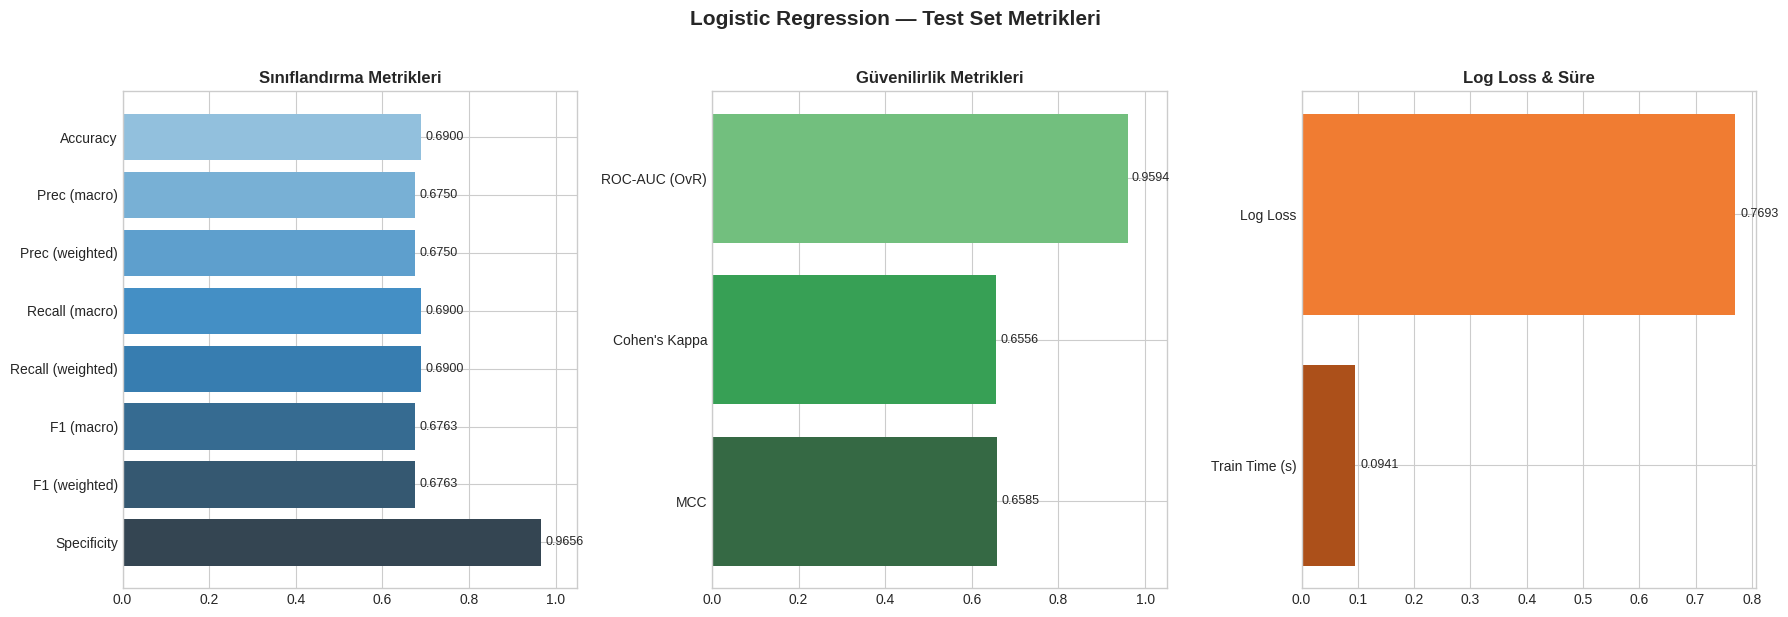

In [36]:
plot_single_model_metrics(logreg_test_metrics, "Logistic Regression", "Test")

#### 7.1.7. Confusion Matrix

- Hangi genre'nin hangi genre ile karıştırıldığını gösterir.
- Çapraz (diagonal) değerler doğru tahminler, diğerleri hatalar.

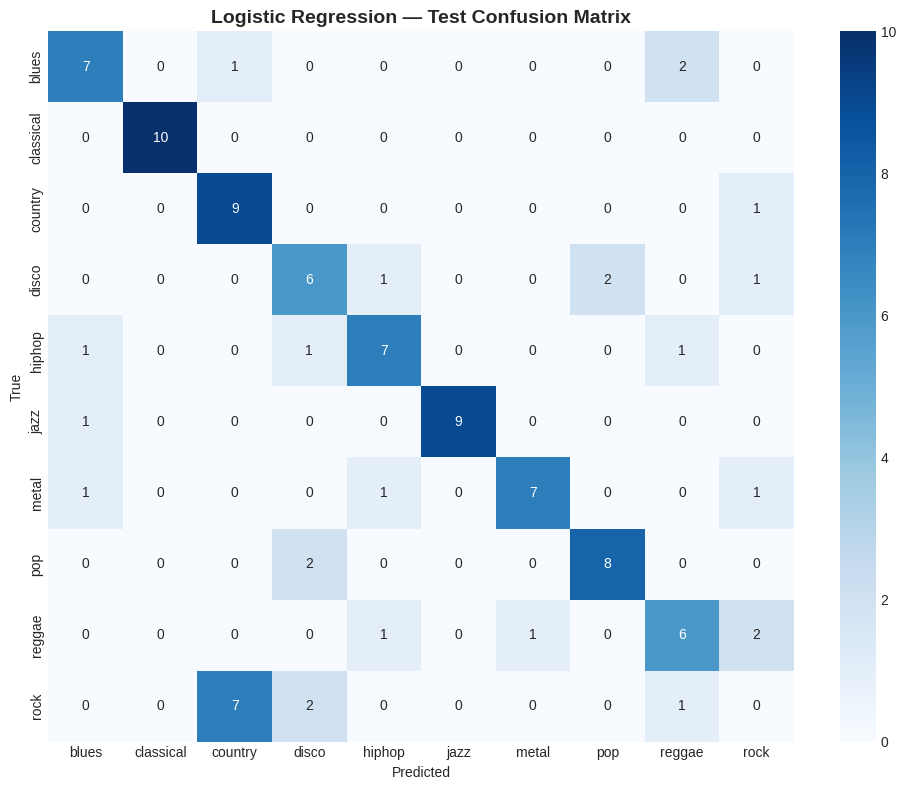

In [37]:
plot_confusion_matrix(
    cm=logreg_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="Logistic Regression",
    dataset_name="Test"
)

### 7.2. Random Forest

#### 7.2.1. Model Eğitimi

In [38]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model, rf_train_time = train_model(rf_model, X_train_scaled, y_train)

print(f"Random Forest eğitildi. Süre: {rf_train_time:.2f} saniye")

Random Forest eğitildi. Süre: 1.60 saniye


#### 7.2.2. Değerlendirme

In [39]:
rf_test_metrics = evaluate_model(rf_model, X_test_scaled, y_test, le, rf_train_time)
rf_val_metrics = evaluate_model(rf_model, X_val_scaled, y_val, le, rf_train_time)

print("Değerlendirme tamamlandı.")

Değerlendirme tamamlandı.


#### 7.2.3. Classification Report

In [40]:
# === RANDOM FOREST — Classification Report ===
print("=== Test Classification Report ===\n")
print(rf_test_metrics["classification_report"])

print("\n=== Validation Classification Report ===\n")
print(rf_val_metrics["classification_report"])

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.60      0.60      0.60        10
   classical       1.00      1.00      1.00        10
     country       0.62      0.80      0.70        10
       disco       0.43      0.60      0.50        10
      hiphop       0.60      0.60      0.60        10
        jazz       1.00      0.90      0.95        10
       metal       1.00      0.70      0.82        10
         pop       0.75      0.90      0.82        10
      reggae       0.67      0.60      0.63        10
        rock       1.00      0.60      0.75        10

    accuracy                           0.73       100
   macro avg       0.77      0.73      0.74       100
weighted avg       0.77      0.73      0.74       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        10
   classical       1.00      0.70      0.82        10

#### 7.2.4. Güvenilirlik Metrikleri

In [41]:
print("specificity:", rf_test_metrics["specificity_macro"])
print("roc-auc:", rf_test_metrics["roc_auc_ovr"])
print("kappa:", rf_test_metrics["cohen_kappa"])
print("mcc:", rf_test_metrics["mcc"])

specificity: 0.97
roc-auc: 0.9546
kappa: 0.7
mcc: 0.7022


#### 7.2.5. Log Loss & Eğitim Süresi

In [42]:
print("log_loss:", rf_test_metrics["log_loss"])
print("train_time:", rf_test_metrics["train_time"], "s")

log_loss: 1.0062
train_time: 1.5996 s


#### 7.2.6. Metrik Görselleştirmesi

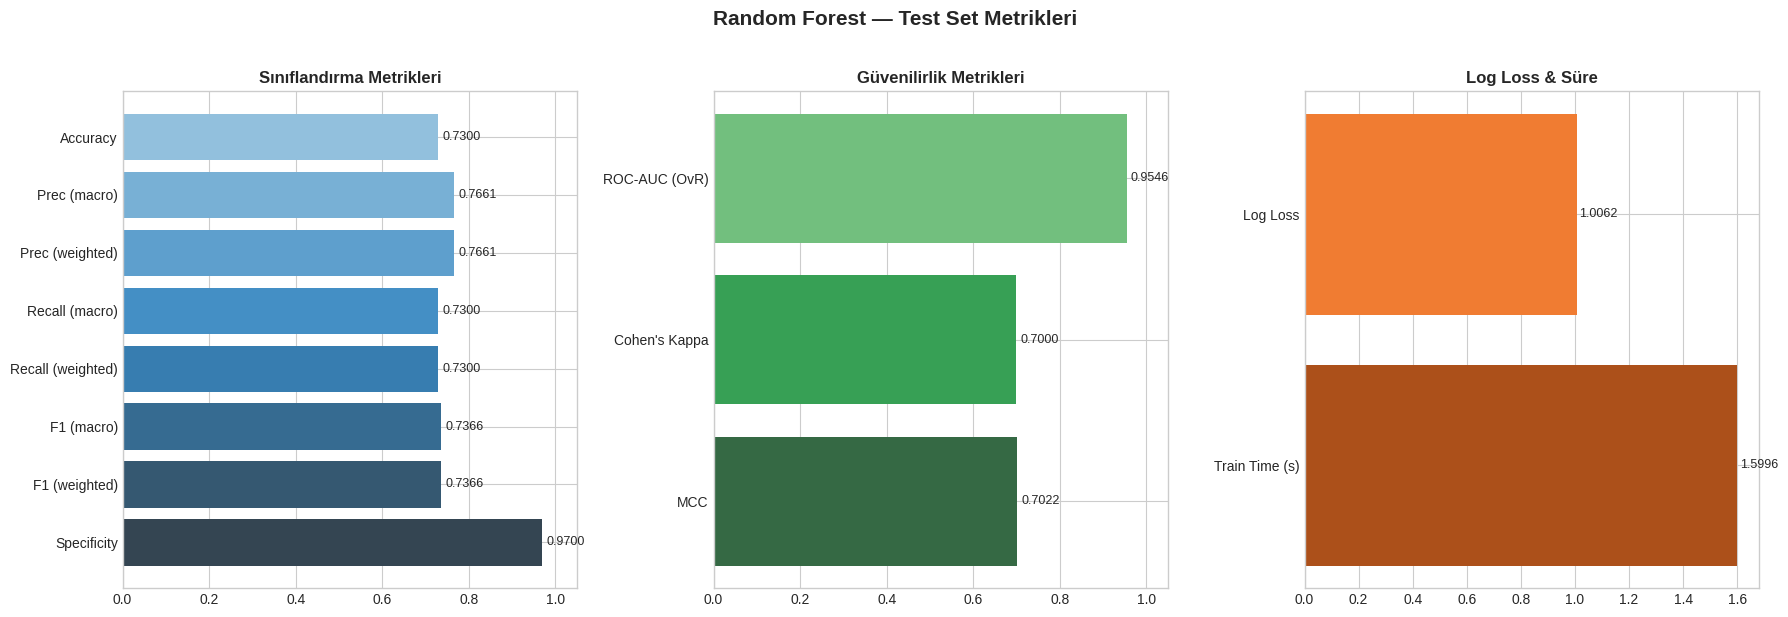

In [43]:
plot_single_model_metrics(rf_test_metrics, "Random Forest", "Test")

#### 7.2.7. Confusion Matrix

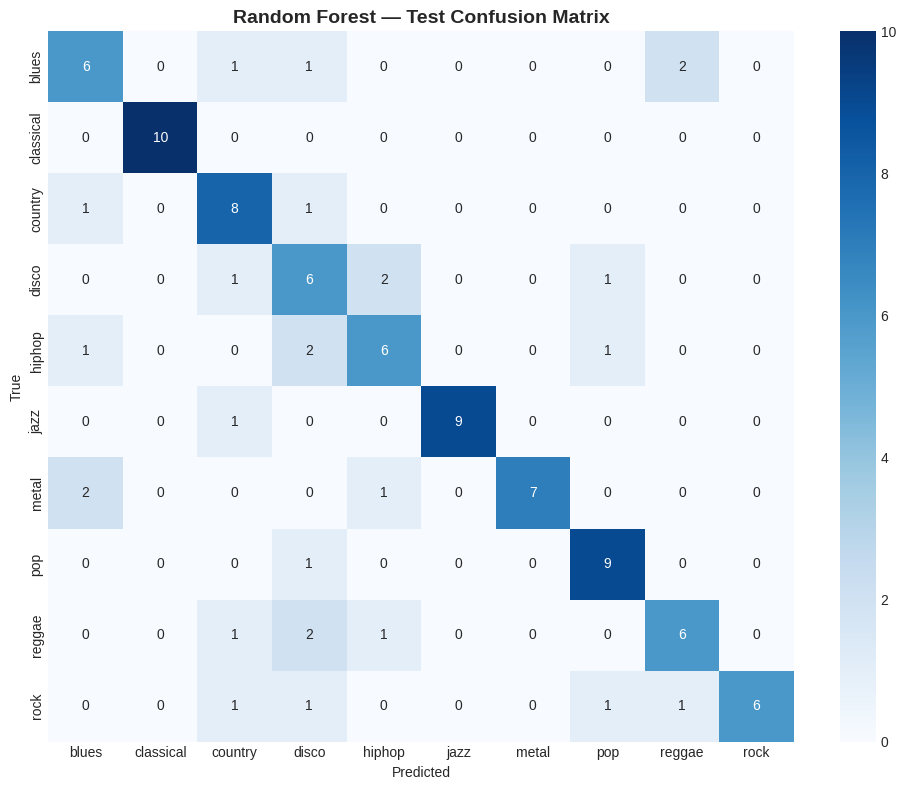

In [44]:
plot_confusion_matrix(
    cm=rf_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="Random Forest",
    dataset_name="Test"
)

### 7.3. SVM

#### 7.3.1. Model Eğitimi

In [45]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model, svm_train_time = train_model(svm_model, X_train_scaled, y_train)

print(f"SVM eğitildi. Süre: {svm_train_time:.2f} saniye")

SVM eğitildi. Süre: 0.20 saniye


#### 7.3.2. Değerlendirme

In [46]:
svm_test_metrics = evaluate_model(svm_model, X_test_scaled, y_test, le, svm_train_time)
svm_val_metrics = evaluate_model(svm_model, X_val_scaled, y_val, le, svm_train_time)

print("Değerlendirme tamamlandı.")

Değerlendirme tamamlandı.


#### 7.3.3. Classification Report

In [47]:
print("=== Test Classification Report ===\n")
print(svm_test_metrics["classification_report"])

print("\n=== Validation Classification Report ===\n")
print(svm_val_metrics["classification_report"])

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        10
   classical       1.00      1.00      1.00        10
     country       0.64      0.90      0.75        10
       disco       0.50      0.50      0.50        10
      hiphop       0.75      0.60      0.67        10
        jazz       0.90      0.90      0.90        10
       metal       0.88      0.70      0.78        10
         pop       0.58      0.70      0.64        10
      reggae       0.64      0.70      0.67        10
        rock       0.44      0.40      0.42        10

    accuracy                           0.70       100
   macro avg       0.71      0.70      0.70       100
weighted avg       0.71      0.70      0.70       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        10
   classical       1.00      0.90      0.95        10

#### 7.3.4. Güvenilirlik Metrikleri

In [48]:
print("specificity:", svm_test_metrics["specificity_macro"])
print("roc-auc:", svm_test_metrics["roc_auc_ovr"])
print("kappa:", svm_test_metrics["cohen_kappa"])
print("mcc:", svm_test_metrics["mcc"])

specificity: 0.9667
roc-auc: 0.9579
kappa: 0.6667
mcc: 0.6679


#### 7.3.5. Log Loss & Eğitim Süresi

In [49]:
print("log_loss:", svm_test_metrics["log_loss"])
print("train_time:", svm_test_metrics["train_time"], "s")

log_loss: 0.8324
train_time: 0.2009 s


#### 7.3.6. Metrik Görselleştirmesi

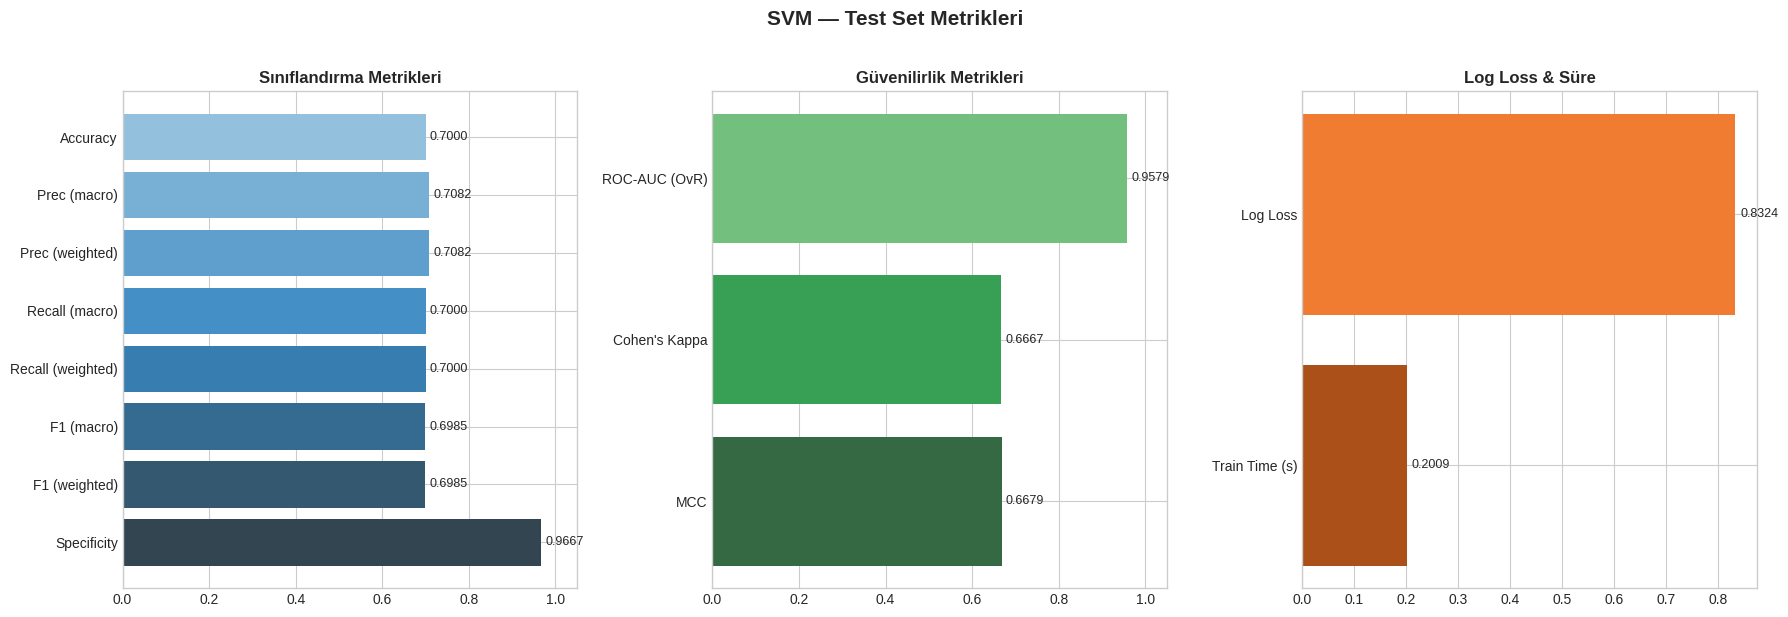

In [50]:
plot_single_model_metrics(svm_test_metrics, "SVM", "Test")

#### 7.3.7. Confusion Matrix

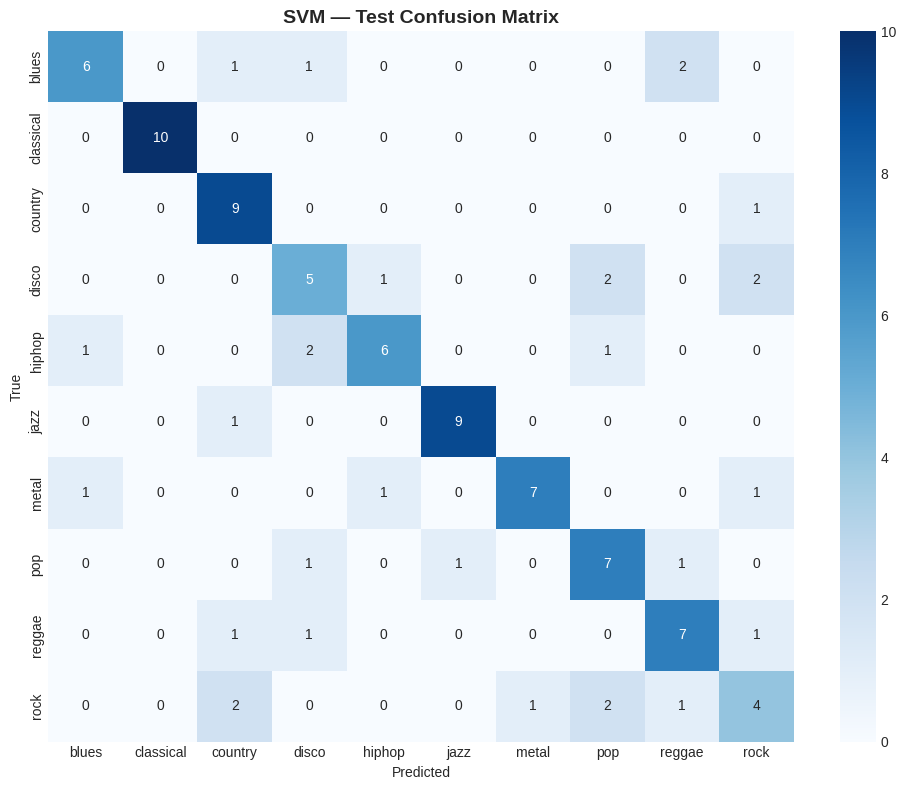

In [51]:
plot_confusion_matrix(
    cm=svm_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="SVM",
    dataset_name="Test"
)

### 7.4. KNN

#### 7.4.1. Model Eğitimi

In [52]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn_model, knn_train_time = train_model(knn_model, X_train_scaled, y_train)

print(f"KNN eğitildi. Süre: {knn_train_time:.2f} saniye")

KNN eğitildi. Süre: 0.00 saniye


#### 7.4.2. Değerlendirme

In [53]:
# === KNN — Değerlendirme ===
knn_test_metrics = evaluate_model(knn_model, X_test_scaled, y_test, le, knn_train_time)
knn_val_metrics = evaluate_model(knn_model, X_val_scaled, y_val, le, knn_train_time)

print("Değerlendirme tamamlandı.")

Değerlendirme tamamlandı.


#### 7.4.3. Classification Report

In [54]:
print("=== Test Classification Report ===\n")
print(knn_test_metrics["classification_report"])

print("\n=== Validation Classification Report ===\n")
print(knn_val_metrics["classification_report"])

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.67      0.40      0.50        10
   classical       0.82      0.90      0.86        10
     country       0.56      0.90      0.69        10
       disco       0.40      0.40      0.40        10
      hiphop       0.70      0.70      0.70        10
        jazz       0.88      0.70      0.78        10
       metal       0.88      0.70      0.78        10
         pop       0.62      0.80      0.70        10
      reggae       0.46      0.60      0.52        10
        rock       0.80      0.40      0.53        10

    accuracy                           0.65       100
   macro avg       0.68      0.65      0.65       100
weighted avg       0.68      0.65      0.65       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       0.86      0.60      0.71        10
   classical       0.82      0.90      0.86        10

#### 7.4.4. Güvenilirlik Metrikleri

In [55]:
print("specificity:", knn_test_metrics["specificity_macro"])
print("roc-auc:", knn_test_metrics["roc_auc_ovr"])
print("kappa:", knn_test_metrics["cohen_kappa"])
print("mcc:", knn_test_metrics["mcc"])

specificity: 0.9611
roc-auc: 0.9122
kappa: 0.6111
mcc: 0.6147


#### 7.4.5. Log Loss & Eğitim Süresi

In [56]:
print("log_loss:", knn_test_metrics["log_loss"])
print("train_time:", knn_test_metrics["train_time"], "s")

log_loss: 4.4471
train_time: 0.0029 s


#### 7.4.6. Metrik Görselleştirmesi

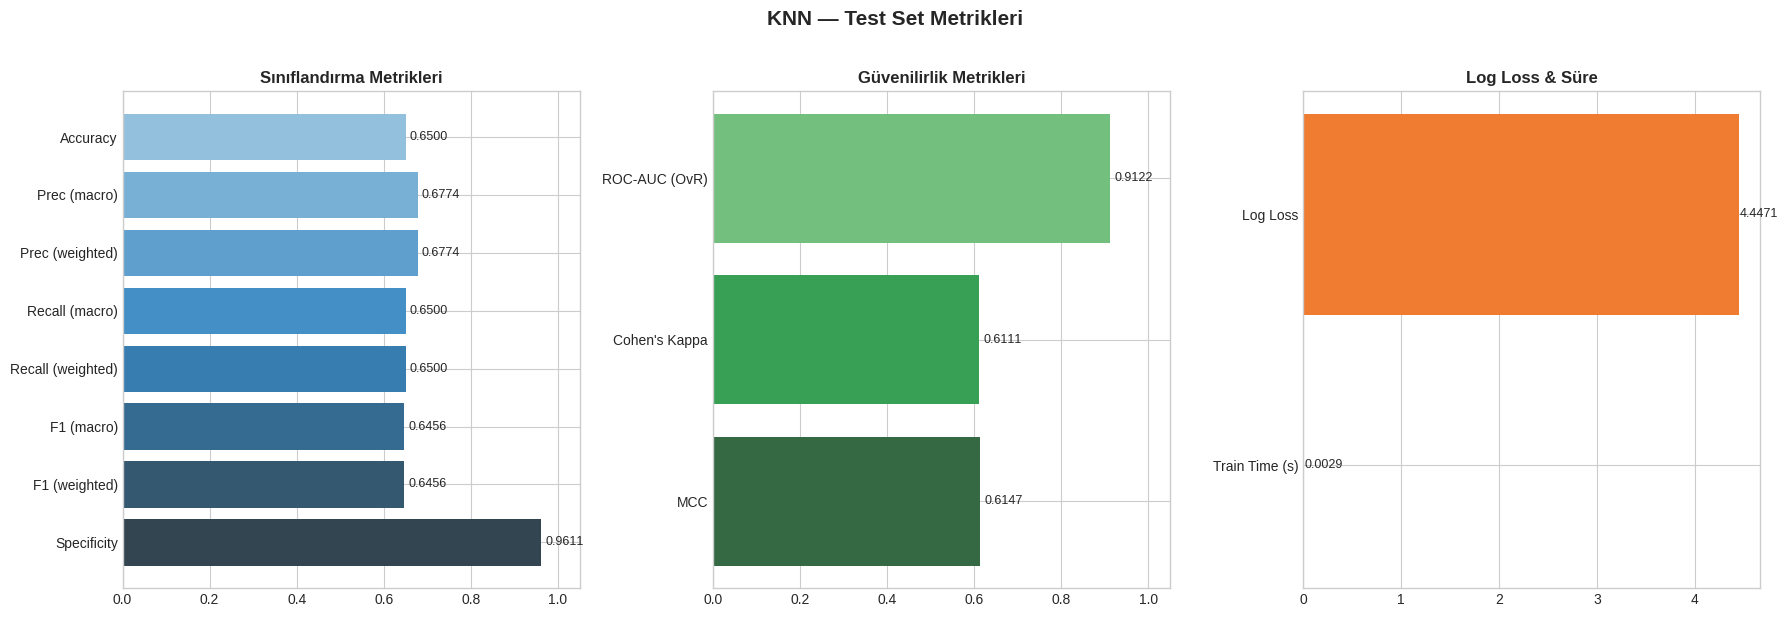

In [57]:
plot_single_model_metrics(knn_test_metrics, "KNN", "Test")

#### 7.4.7. Confusion Matrix

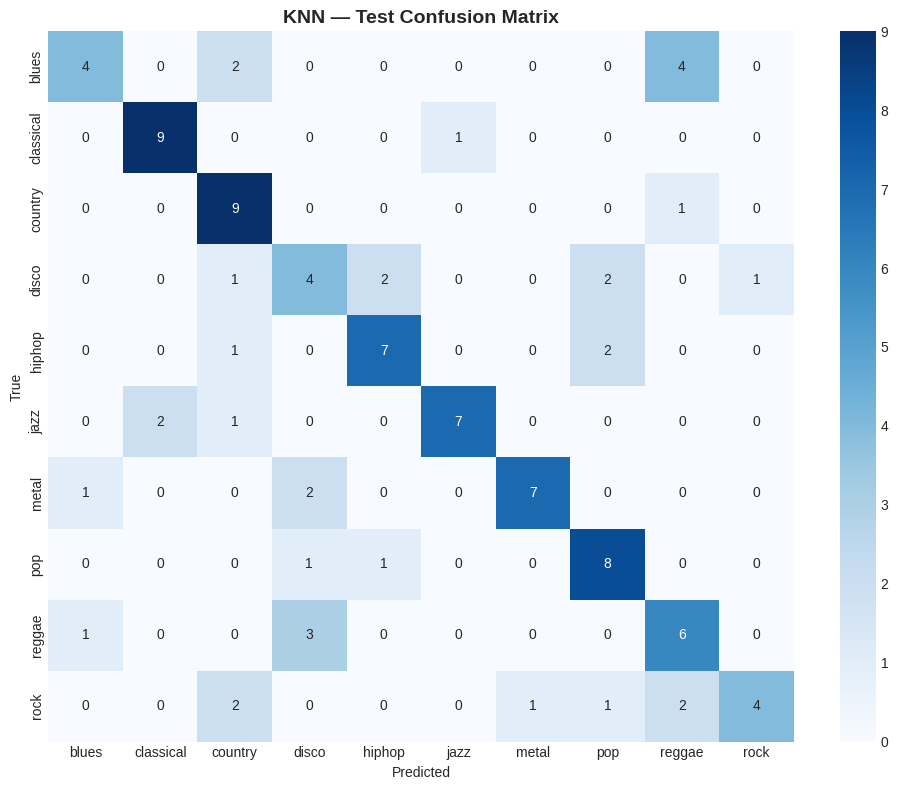

In [58]:
plot_confusion_matrix(
    cm=knn_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="KNN",
    dataset_name="Test"
)

### 7.5. XGBoost

#### 7.5.1. Model Eğitimi

In [59]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_model, xgb_train_time = train_model(xgb_model, X_train_scaled, y_train)

print(f"XGBoost eğitildi. Süre: {xgb_train_time:.2f} saniye")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:18:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost eğitildi. Süre: 8.06 saniye


#### 7.5.2. Değerlendirme

In [60]:
xgb_test_metrics = evaluate_model(xgb_model, X_test_scaled, y_test, le, xgb_train_time)
xgb_val_metrics = evaluate_model(xgb_model, X_val_scaled, y_val, le, xgb_train_time)

print("Değerlendirme tamamlandı.")

Değerlendirme tamamlandı.


#### 7.5.3. Classification Report

In [61]:
print("=== Test Classification Report ===\n")
print(xgb_test_metrics["classification_report"])

print("\n=== Validation Classification Report ===\n")
print(xgb_val_metrics["classification_report"])

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.64      0.70      0.67        10
   classical       1.00      1.00      1.00        10
     country       0.56      0.90      0.69        10
       disco       0.46      0.60      0.52        10
      hiphop       0.46      0.60      0.52        10
        jazz       1.00      0.90      0.95        10
       metal       1.00      0.50      0.67        10
         pop       0.73      0.80      0.76        10
      reggae       0.80      0.40      0.53        10
        rock       0.43      0.30      0.35        10

    accuracy                           0.67       100
   macro avg       0.71      0.67      0.67       100
weighted avg       0.71      0.67      0.67       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       0.64      0.70      0.67        10
   classical       0.70      0.70      0.70        10

#### 7.5.4. Güvenilirlik Metrikleri

In [62]:
print("specificity:", xgb_test_metrics["specificity_macro"])
print("roc-auc:", xgb_test_metrics["roc_auc_ovr"])
print("kappa:", xgb_test_metrics["cohen_kappa"])
print("mcc:", xgb_test_metrics["mcc"])

specificity: 0.9633
roc-auc: 0.9399
kappa: 0.6333
mcc: 0.6375


#### 7.5.5. Log Loss & Eğitim Süresi

In [63]:
print("log_loss:", xgb_test_metrics["log_loss"])
print("train_time:", xgb_test_metrics["train_time"], "s")

log_loss: 1.015
train_time: 8.0617 s


#### 7.5.6. Metrik Görselleştirmesi

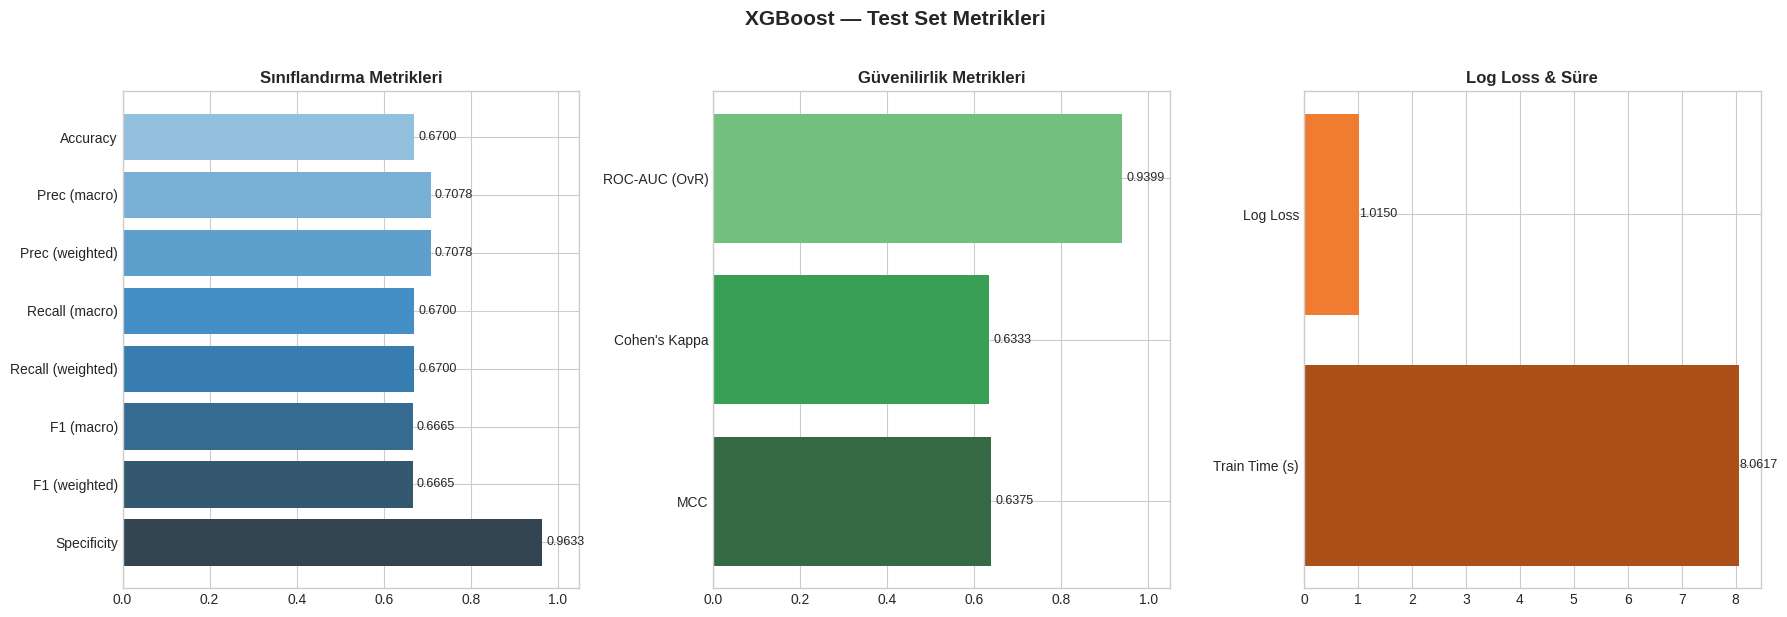

In [64]:
plot_single_model_metrics(xgb_test_metrics, "XGBoost", "Test")

#### 7.5.7. Confusion Matrix

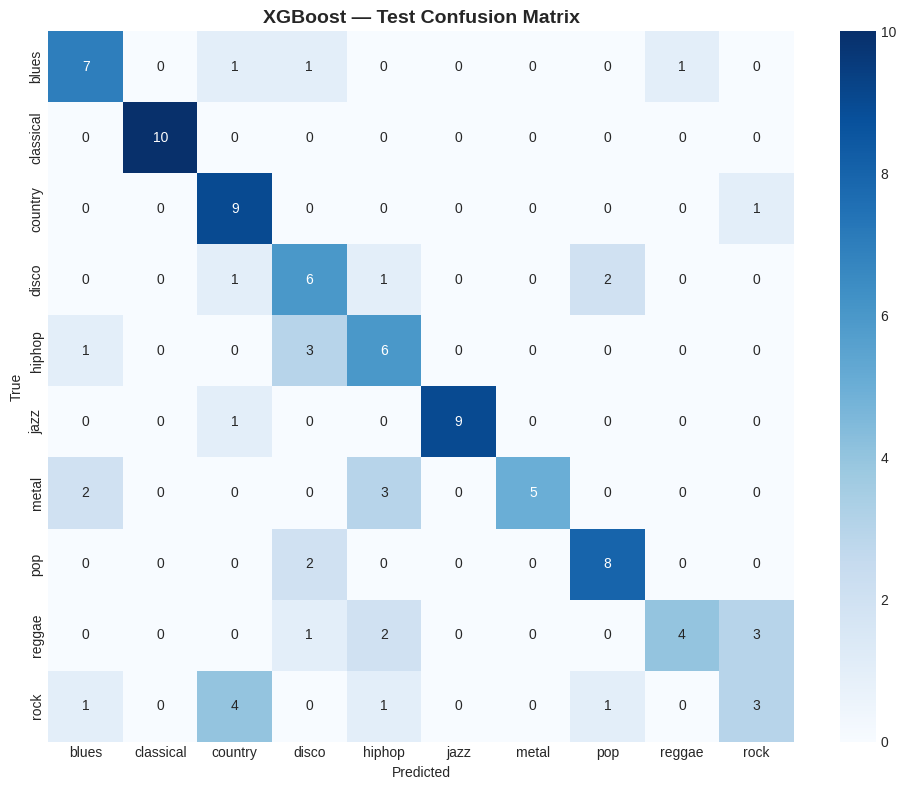

In [65]:
plot_confusion_matrix(
    cm=xgb_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="XGBoost",
    dataset_name="Test"
)

### 7.6. MLP


#### 7.6.1. Model Eğitimi

In [66]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp_model, mlp_train_time = train_model(mlp_model, X_train_scaled, y_train)

print(f"MLP eğitildi. Süre: {mlp_train_time:.2f} saniye")

MLP eğitildi. Süre: 0.76 saniye


#### 7.6.2. Değerlendirme

In [67]:
mlp_test_metrics = evaluate_model(mlp_model, X_test_scaled, y_test, le, mlp_train_time)
mlp_val_metrics = evaluate_model(mlp_model, X_val_scaled, y_val, le, mlp_train_time)

print("Değerlendirme tamamlandı.")

Değerlendirme tamamlandı.


#### 7.6.3. Classification Report

In [68]:
print("=== Test Classification Report ===\n")
print(mlp_test_metrics["classification_report"])

print("\n=== Validation Classification Report ===\n")
print(mlp_val_metrics["classification_report"])

=== Test Classification Report ===

              precision    recall  f1-score   support

       blues       0.80      0.80      0.80        10
   classical       0.90      0.90      0.90        10
     country       0.64      0.90      0.75        10
       disco       0.50      0.60      0.55        10
      hiphop       0.86      0.60      0.71        10
        jazz       0.89      0.80      0.84        10
       metal       0.89      0.80      0.84        10
         pop       0.62      0.80      0.70        10
      reggae       0.70      0.70      0.70        10
        rock       0.50      0.30      0.38        10

    accuracy                           0.72       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.72      0.72       100


=== Validation Classification Report ===

              precision    recall  f1-score   support

       blues       0.82      0.90      0.86        10
   classical       0.80      0.80      0.80        10

#### 7.6.4. Güvenilirlik Metrikleri

In [69]:
print("specificity:", mlp_test_metrics["specificity_macro"])
print("roc-auc:", mlp_test_metrics["roc_auc_ovr"])
print("kappa:", mlp_test_metrics["cohen_kappa"])
print("mcc:", mlp_test_metrics["mcc"])

specificity: 0.9689
roc-auc: 0.9569
kappa: 0.6889
mcc: 0.691


#### 7.6.5. Log Loss & Eğitim Süresi

In [70]:
print("log_loss:", mlp_test_metrics["log_loss"])
print("train_time:", mlp_test_metrics["train_time"], "s")

log_loss: 0.8252
train_time: 0.7567 s


#### 7.6.6. Metrik Görselleştirmesi

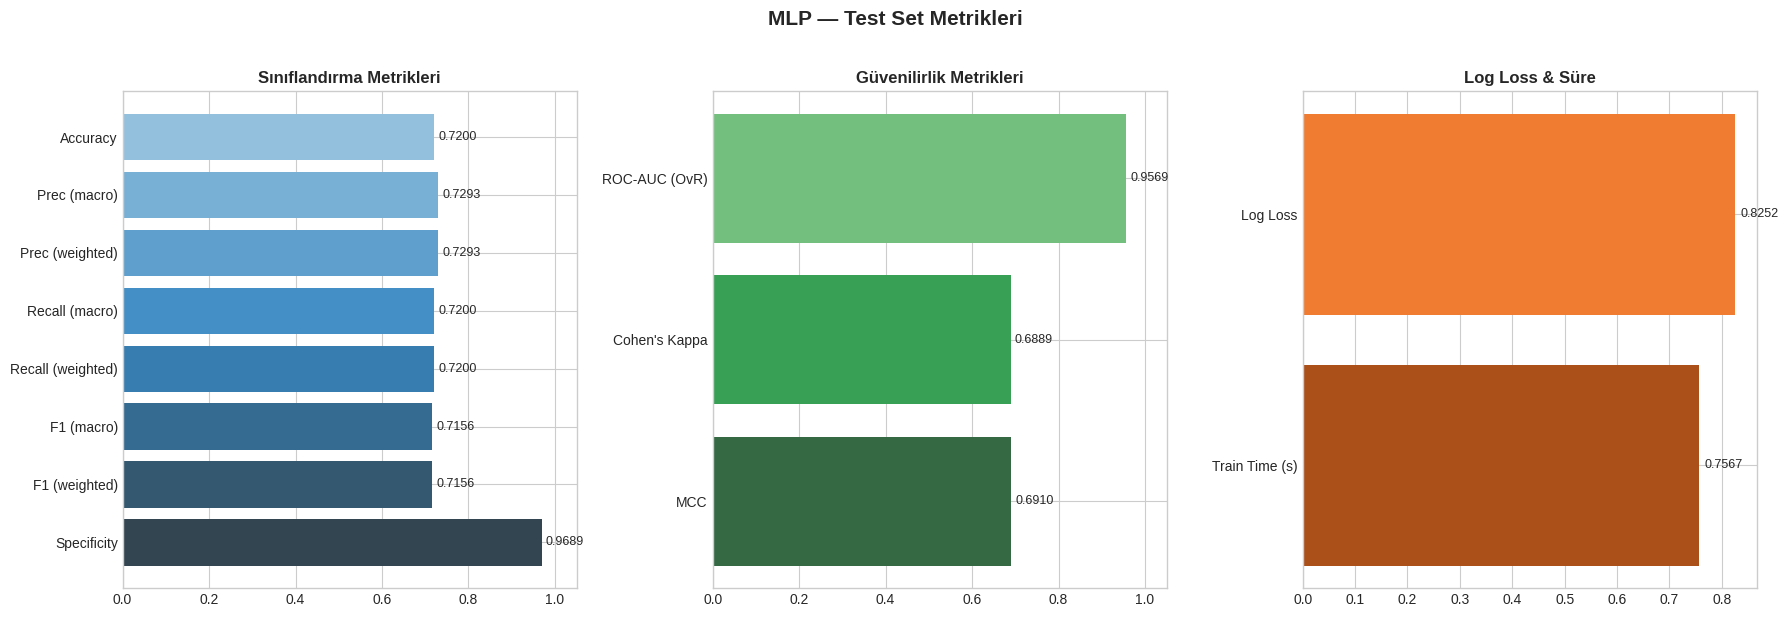

In [71]:
plot_single_model_metrics(mlp_test_metrics, "MLP", "Test")

#### 7.6.7. Confusion Matrix

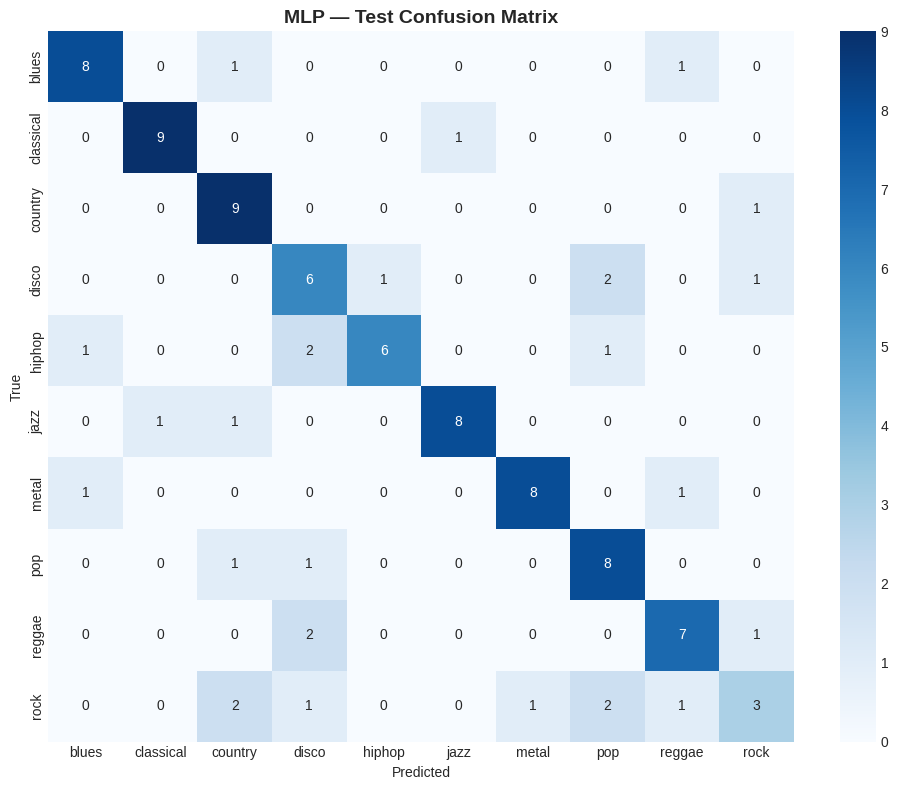

In [72]:
plot_confusion_matrix(
    cm=mlp_test_metrics["confusion_matrix"],
    class_names=le.classes_,
    model_name="MLP",
    dataset_name="Test"
)

## 8. Tüm Modellerin Karşılaştırılması

- Buradaki karşılaştırma, modellerin her birinin tek bir parametre setiyle tek bir eğitim süreci sonuçlarının karşılaştırmasıdır.

### 8.1. Genel Karşılaştırma Tablosu

In [73]:
# Tüm baseline sonuçları tek sözlükte topluyoruz

all_results = {
    "Logistic Regression": logreg_test_metrics,
    "Random Forest": rf_test_metrics,
    "SVM": svm_test_metrics,
    "KNN": knn_test_metrics,
    "XGBoost": xgb_test_metrics,
    "MLP": mlp_test_metrics,
}

comparison_df = collect_all_results(all_results, "Test")
comparison_df

,Logistic Regression,Random Forest,SVM,KNN,XGBoost,MLP
Metric,,,,,,
accuracy,0.6900,0.7300,0.7000,0.6500,0.6700,0.7200
precision_macro,0.6750,0.7661,0.7082,0.6774,0.7078,0.7293
precision_weighted,0.6750,0.7661,0.7082,0.6774,0.7078,0.7293
recall_macro,0.6900,0.7300,0.7000,0.6500,0.6700,0.7200
recall_weighted,0.6900,0.7300,0.7000,0.6500,0.6700,0.7200
f1_macro,0.6763,0.7366,0.6985,0.6456,0.6665,0.7156
f1_weighted,0.6763,0.7366,0.6985,0.6456,0.6665,0.7156
specificity_macro,0.9656,0.9700,0.9667,0.9611,0.9633,0.9689
roc_auc_ovr,0.9594,0.9546,0.9579,0.9122,0.9399,0.9569


### 8.2. Heatmap

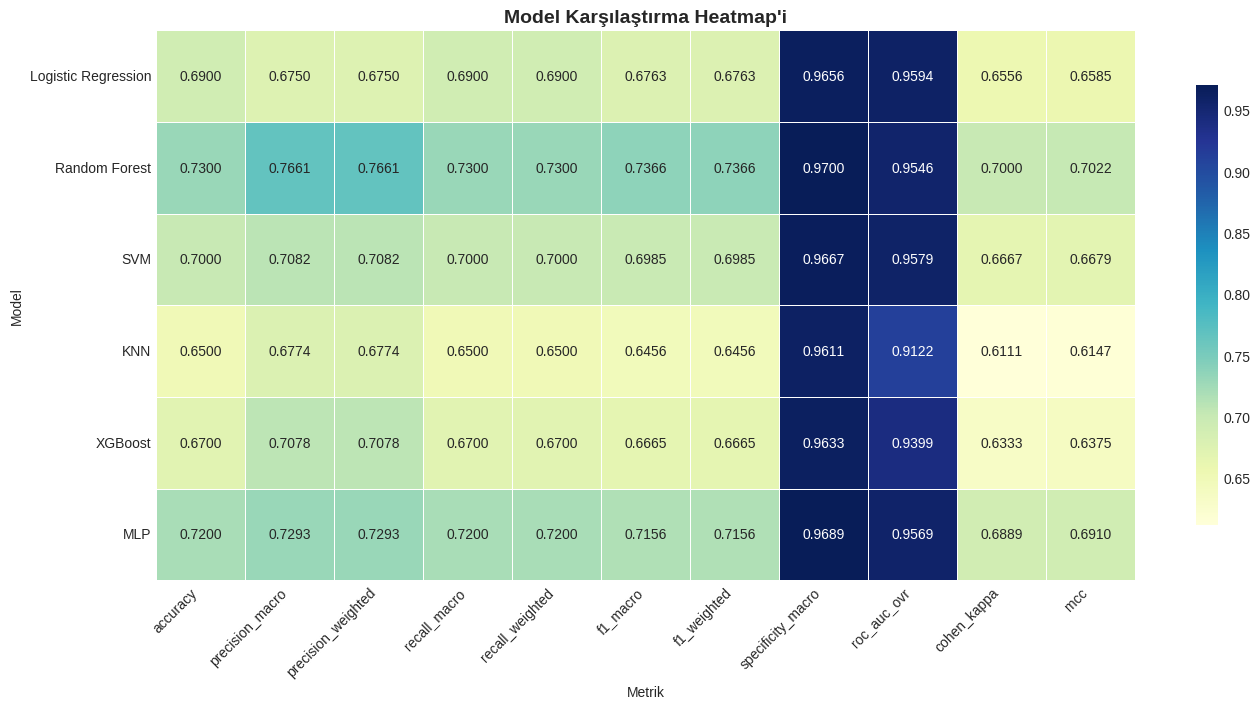

In [74]:
plot_model_comparison_heatmap(all_results, metric_keys=[
    "accuracy", "precision_macro", "precision_weighted",
    "recall_macro", "recall_weighted", "f1_macro", "f1_weighted",
    "specificity_macro", "roc_auc_ovr", "cohen_kappa", "mcc"
])

### 8.3. Sınıflandırma Metrikleri Karşılaştırması

/content/drive/MyDrive/MusicGenreClassification/src/visualize.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


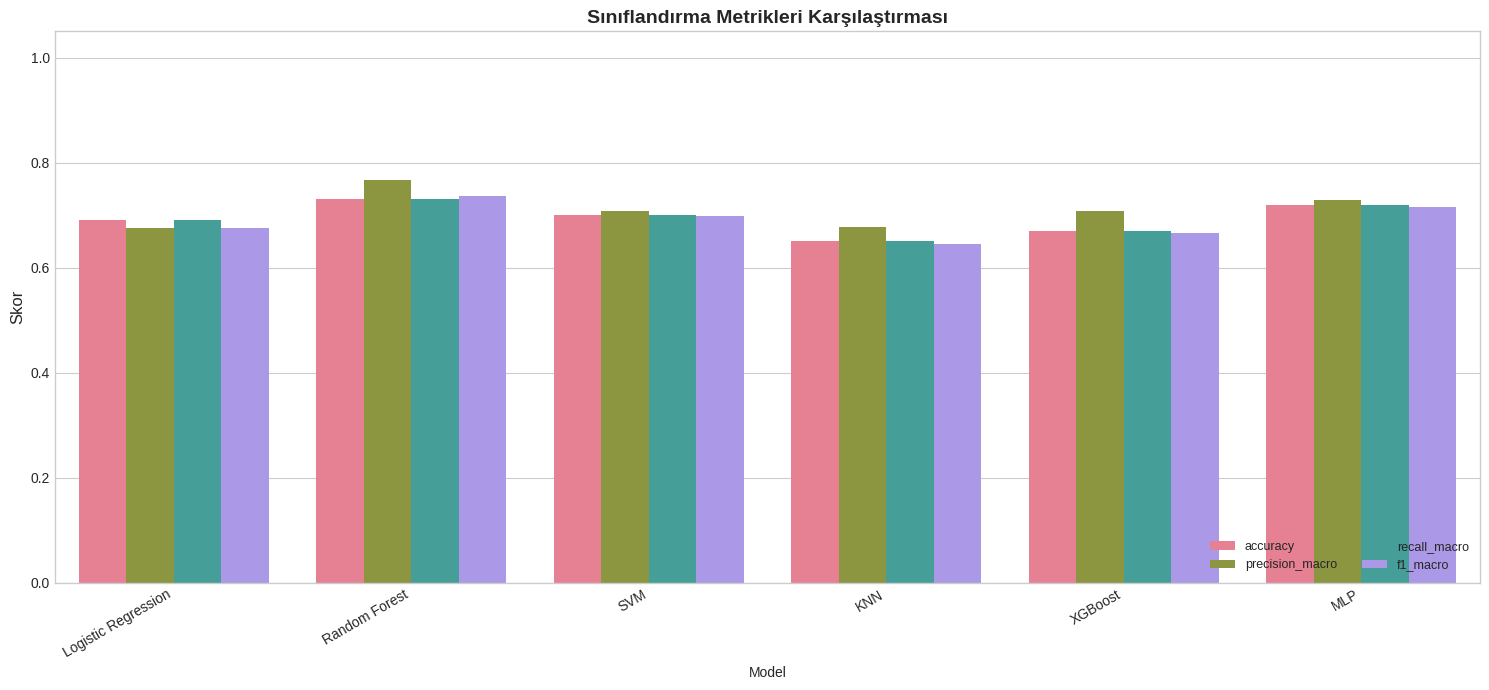

In [75]:
plot_model_comparison(all_results,
    metric_keys=["accuracy", "precision_macro", "recall_macro", "f1_macro"],
    title="Sınıflandırma Metrikleri Karşılaştırması"
)

### 8.4. Güvenilirlik Metrikleri Karşılaştırması

/content/drive/MyDrive/MusicGenreClassification/src/visualize.py:138: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


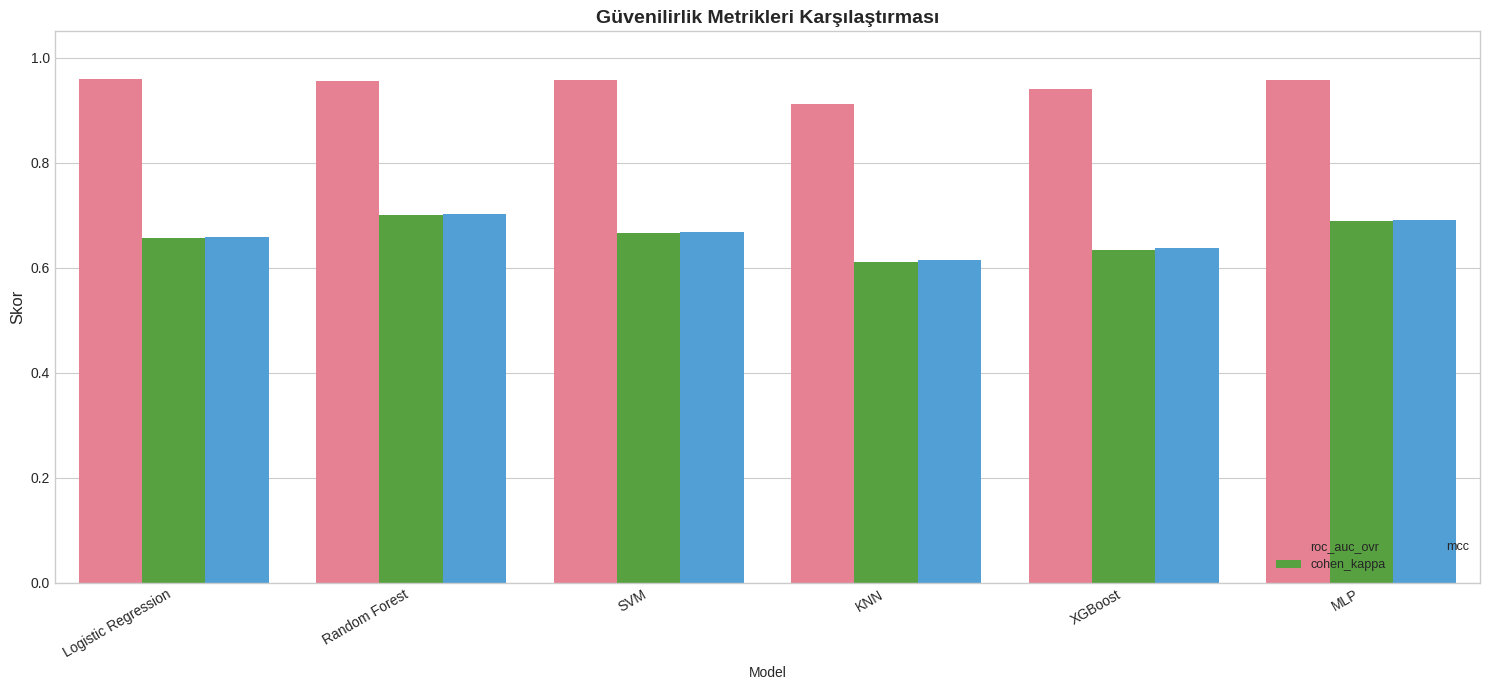

In [76]:
plot_model_comparison(all_results,
    metric_keys=["roc_auc_ovr", "cohen_kappa", "mcc"],
    title="Güvenilirlik Metrikleri Karşılaştırması"
)

### 8.5. Eğitim Süreleri Karşılaştırması

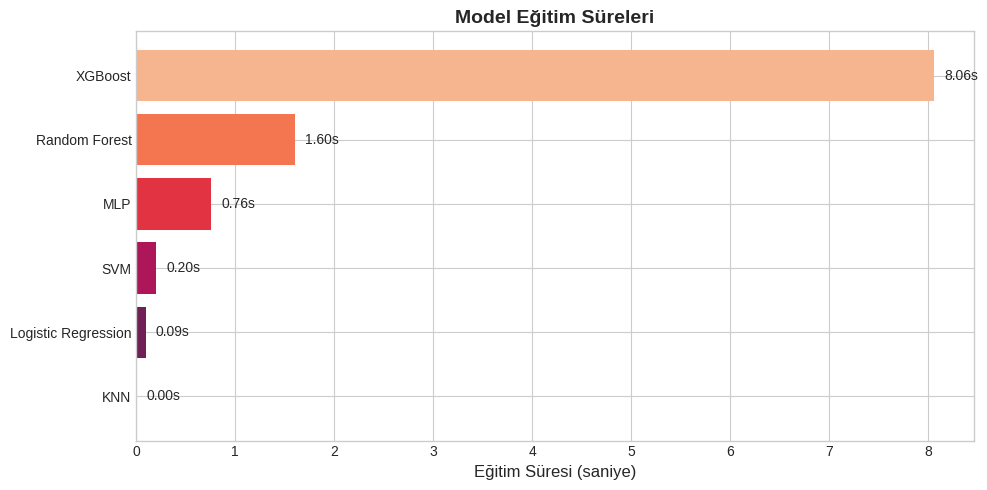

In [77]:
plot_training_time_comparison(all_results)

### 8.6. Log Loss Karşılaştırması

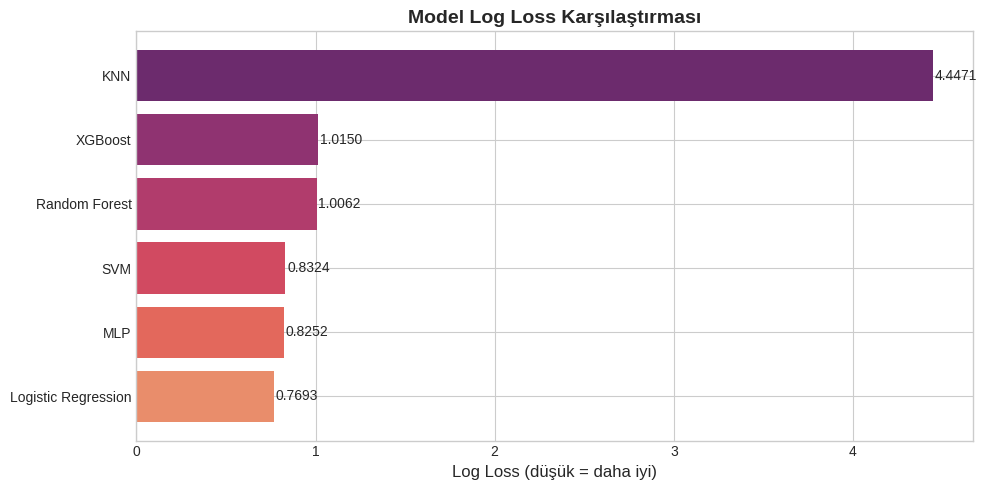

In [78]:
plot_log_loss_comparison(all_results)

### 8.7. ROC Eğrileri

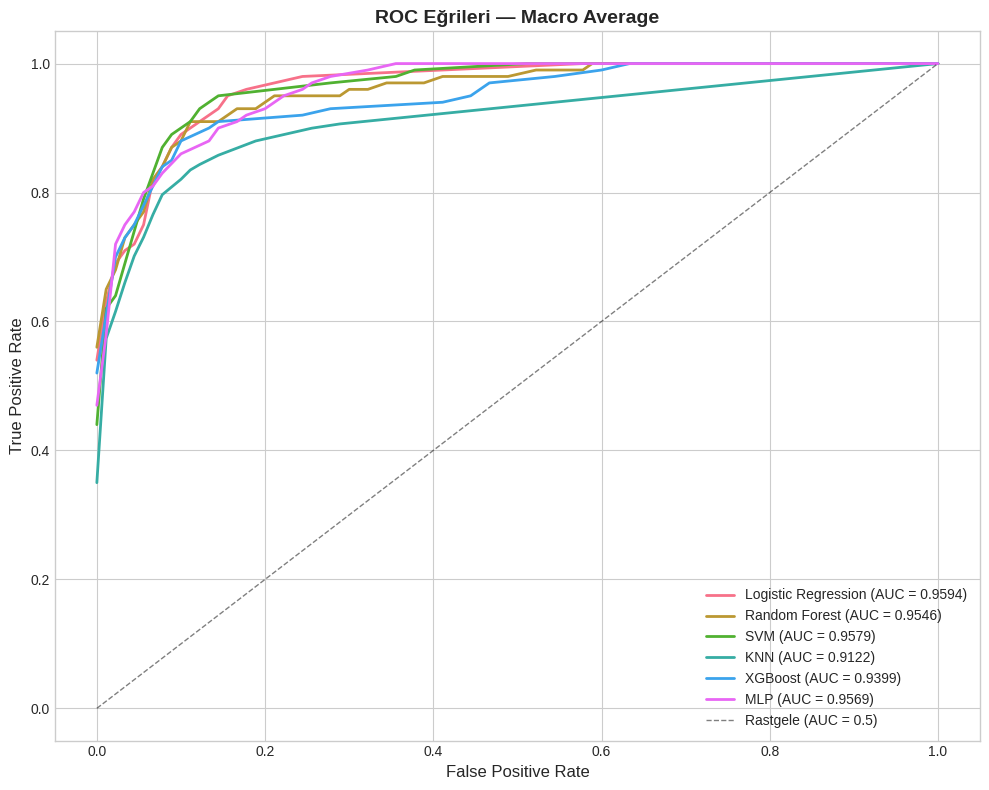

In [79]:
all_models = {
    "Logistic Regression": log_reg_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model,
    "XGBoost": xgb_model,
    "MLP": mlp_model,
}

plot_roc_curves(all_models, X_test_scaled, y_test, le)

### 8.8. Tüm Karışıklık Matrisleri

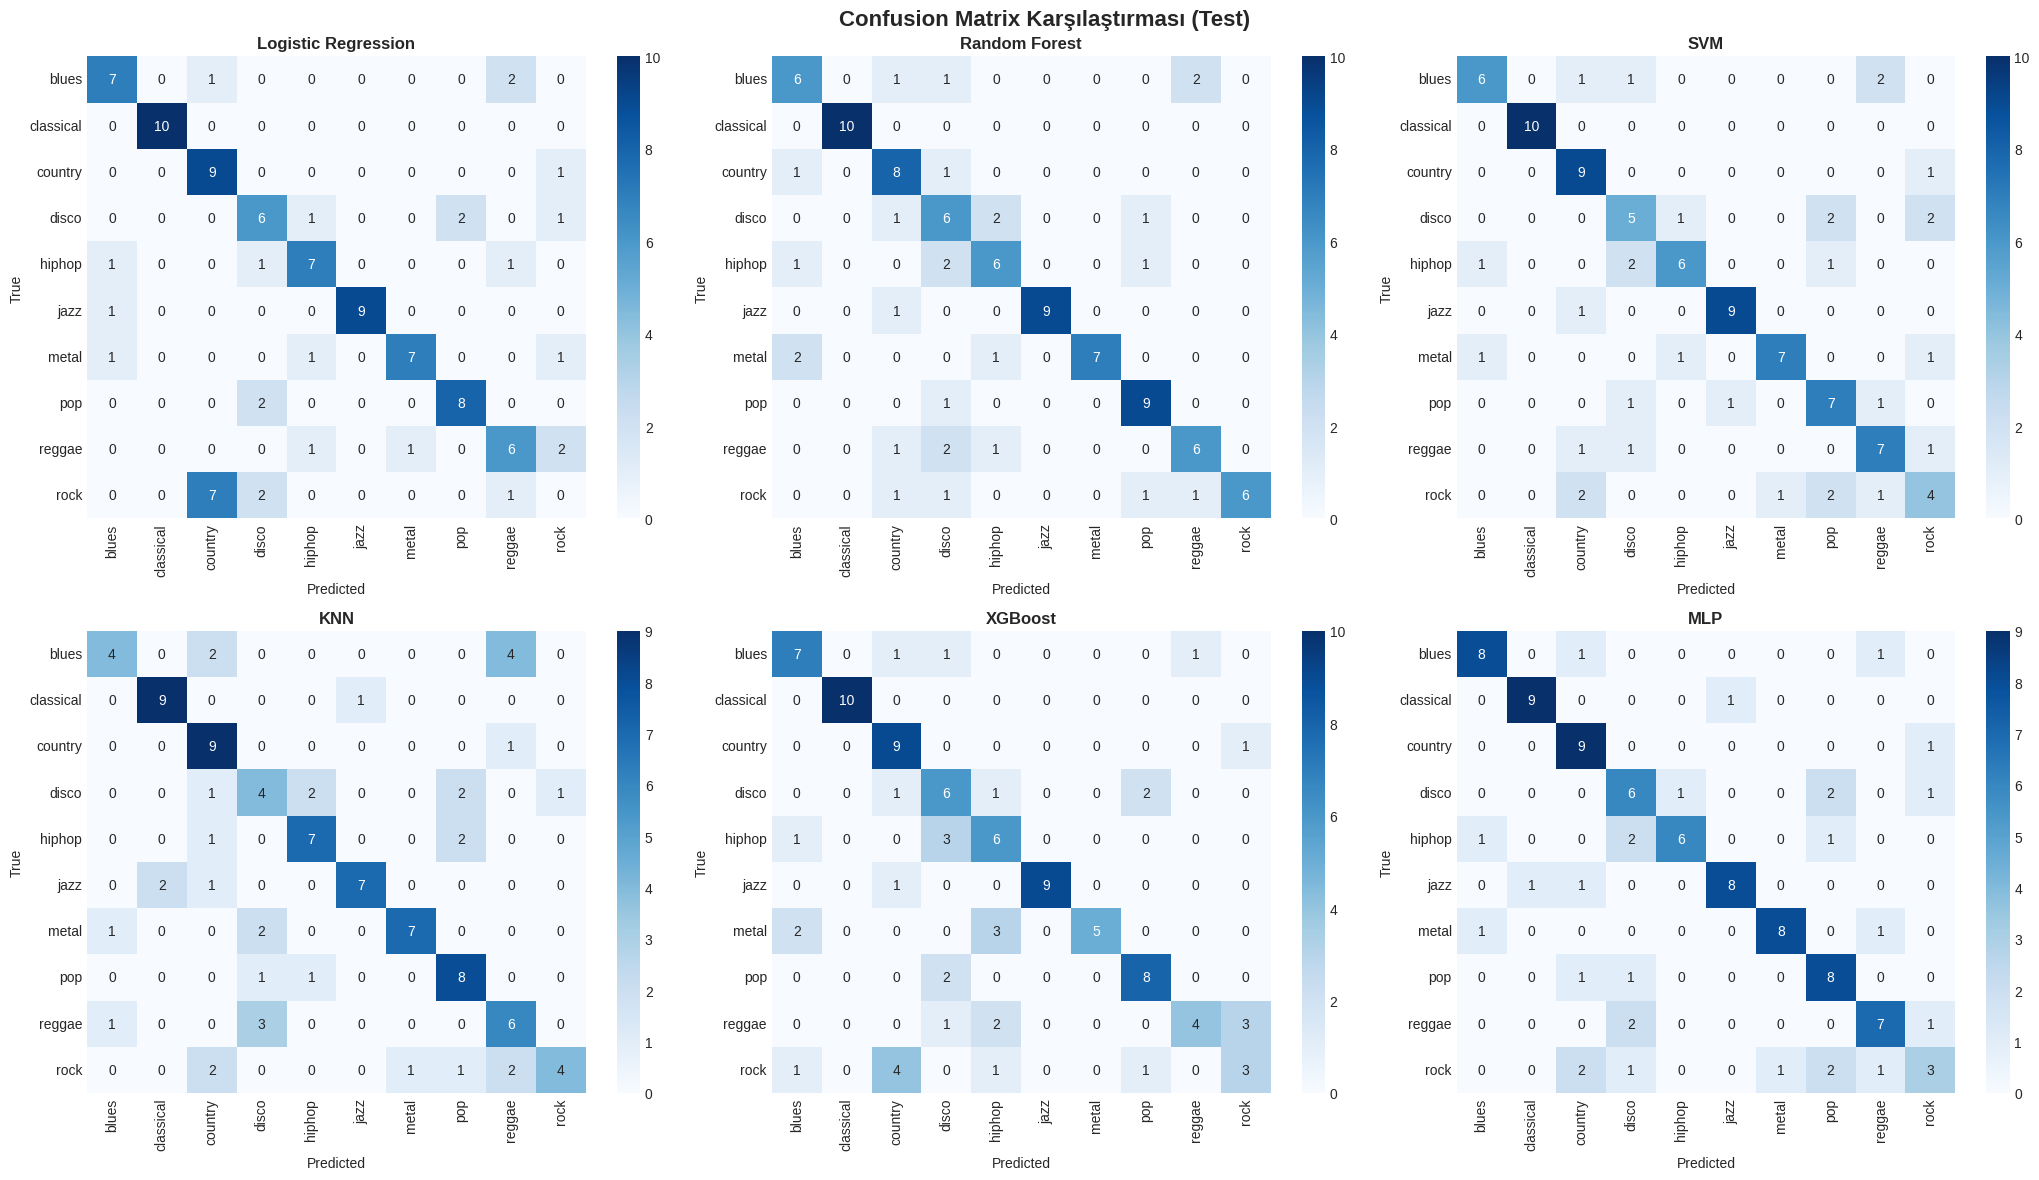

In [80]:
plot_all_confusion_matrices(all_results, le.classes_, "Test")

## 9. GridSearchCV — Hiperparametre Optimizasyonu

### 9.1. Logistic Regression

In [81]:
# Grid Search

logreg_params = {
    "C": [0.01, 0.1, 1, 10], # modelin esnekliği (küçük → basit, büyük → karmaşık)
    "solver": ["lbfgs", "saga"], # optimizasyon yöntemi
    "max_iter": [3000], # maksimum iterasyon (öğrenme süresi)
}

logreg_gs = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=logreg_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
logreg_gs.fit(X_train_scaled, y_train)
logreg_gs_time = time.time() - start_time

print(f"En iyi parametreler: {logreg_gs.best_params_}")
print(f"En iyi CV skoru: {logreg_gs.best_score_:.4f}")
print(f"Arama süresi: {logreg_gs_time:.2f} saniye")

En iyi parametreler: {'C': 1, 'max_iter': 3000, 'solver': 'lbfgs'}
En iyi CV skoru: 0.6884
Arama süresi: 19.14 saniye


In [82]:
# Değerlendirme

logreg_best = logreg_gs.best_estimator_

logreg_gs_test_metrics = evaluate_model(logreg_best, X_test_scaled, y_test, le, logreg_gs_time)

print("Baseline accuracy:", logreg_test_metrics["accuracy"])
print("GridSearch accuracy:", logreg_gs_test_metrics["accuracy"])
print("Fark:", round(logreg_gs_test_metrics["accuracy"] - logreg_test_metrics["accuracy"], 4))

Baseline accuracy: 0.69
GridSearch accuracy: 0.69
Fark: 0.0


### 9.2. Random Forest

In [83]:
# Grid Search

rf_params = {
    "n_estimators": [100, 300, 500], # ağaç sayısı (fazla → daha stabil)
    "max_depth": [10, 20, None], # ağacın derinliği (derin → overfit riski)
    "min_samples_split": [2, 5],  # bölmek için minimum örnek sayısı (büyük → daha genel model)
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
rf_gs.fit(X_train_scaled, y_train)
rf_gs_time = time.time() - start_time

print(f"En iyi parametreler: {rf_gs.best_params_}")
print(f"En iyi CV skoru: {rf_gs.best_score_:.4f}")
print(f"Arama süresi: {rf_gs_time:.2f} saniye")

En iyi parametreler: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 500}
En iyi CV skoru: 0.6821
Arama süresi: 135.10 saniye


In [84]:
# Değerlendirme

rf_best = rf_gs.best_estimator_

rf_gs_test_metrics = evaluate_model(rf_best, X_test_scaled, y_test, le, rf_gs_time)

print("Baseline accuracy:", rf_test_metrics["accuracy"])
print("GridSearch accuracy:", rf_gs_test_metrics["accuracy"])
print("Fark:", round(rf_gs_test_metrics["accuracy"] - rf_test_metrics["accuracy"], 4))

Baseline accuracy: 0.73
GridSearch accuracy: 0.74
Fark: 0.01


### 9.3. Support Vector Machine (SVM)

In [85]:
# Grid Search

svm_params = {
    "kernel": ["rbf", "linear", "poly"], # karar sınırının şekli (doğrusal / karmaşık)
    "C": [0.1, 1, 10],  # hata toleransı (büyük → daha az hata, overfit riski)
    "gamma": ["scale", "auto"], # etki alanı (büyük → daha karmaşık karar sınırı)
}

svm_gs = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid=svm_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
svm_gs.fit(X_train_scaled, y_train)
svm_gs_time = time.time() - start_time

print(f"En iyi parametreler: {svm_gs.best_params_}")
print(f"En iyi CV skoru: {svm_gs.best_score_:.4f}")
print(f"Arama süresi: {svm_gs_time:.2f} saniye")

En iyi parametreler: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
En iyi CV skoru: 0.7246
Arama süresi: 15.26 saniye


In [86]:
# Değerlendirme

svm_best = svm_gs.best_estimator_

svm_gs_test_metrics = evaluate_model(svm_best, X_test_scaled, y_test, le, svm_gs_time)

print("Baseline accuracy:", svm_test_metrics["accuracy"])
print("GridSearch accuracy:", svm_gs_test_metrics["accuracy"])
print("Fark:", round(svm_gs_test_metrics["accuracy"] - svm_test_metrics["accuracy"], 4))

Baseline accuracy: 0.7
GridSearch accuracy: 0.73
Fark: 0.03


### 9.4. K-Nearest Neighbors (KNN)

In [87]:
# Grid Search

knn_params = {
    "n_neighbors": [3, 5, 7, 11], # kaç komşuya bakılacak (küçük → hassas, büyük → daha genel)
    "weights": ["uniform", "distance"], # komşuların etkisi (eşit / yakına daha fazla ağırlık)
    "metric": ["minkowski", "euclidean", "manhattan"] # mesafe hesaplama yöntemi
}

knn_gs = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid=knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
knn_gs.fit(X_train_scaled, y_train)
knn_gs_time = time.time() - start_time

print(f"En iyi parametreler: {knn_gs.best_params_}")
print(f"En iyi CV skoru: {knn_gs.best_score_:.4f}")
print(f"Arama süresi: {knn_gs_time:.2f} saniye")

En iyi parametreler: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
En iyi CV skoru: 0.6808
Arama süresi: 1.51 saniye


In [88]:
# Değerlendirme

knn_best = knn_gs.best_estimator_

knn_gs_test_metrics = evaluate_model(knn_best, X_test_scaled, y_test, le, knn_gs_time)

print("Baseline accuracy:", knn_test_metrics["accuracy"])
print("GridSearch accuracy:", knn_gs_test_metrics["accuracy"])
print("Fark:", round(knn_gs_test_metrics["accuracy"] - knn_test_metrics["accuracy"], 4))

Baseline accuracy: 0.65
GridSearch accuracy: 0.69
Fark: 0.04


### 9.5. XGBoost

In [89]:
# Grid Search

xgb_params = {
    "n_estimators": [100, 300, 500], # ağaç sayısı (fazla → daha güçlü ama yavaş)
    "learning_rate": [0.01, 0.1, 0.3], # öğrenme hızı (küçük → daha stabil, büyük → hızlı ama riskli)
    "max_depth": [3, 6, 10], # ağaç derinliği (derin → karmaşık, overfit riski)
}

xgb_gs = GridSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric="mlogloss", n_jobs=-1),
    param_grid=xgb_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
xgb_gs.fit(X_train_scaled, y_train)
xgb_gs_time = time.time() - start_time

print(f"En iyi parametreler: {xgb_gs.best_params_}")
print(f"En iyi CV skoru: {xgb_gs.best_score_:.4f}")
print(f"Arama süresi: {xgb_gs_time:.2f} saniye")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:32:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


En iyi parametreler: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
En iyi CV skoru: 0.6884
Arama süresi: 685.96 saniye


In [90]:
# Değerlendirme

xgb_best = xgb_gs.best_estimator_

xgb_gs_test_metrics = evaluate_model(xgb_best, X_test_scaled, y_test, le, xgb_gs_time)

print("Baseline accuracy:", xgb_test_metrics["accuracy"])
print("GridSearch accuracy:", xgb_gs_test_metrics["accuracy"])
print("Fark:", round(xgb_gs_test_metrics["accuracy"] - xgb_test_metrics["accuracy"], 4))

Baseline accuracy: 0.67
GridSearch accuracy: 0.74
Fark: 0.07


### 9.6. Multi-Layer Perceptron

In [91]:
# Grid Search

mlp_params = {
    "hidden_layer_sizes": [(128,), (256, 128), (512, 256, 128)], # katman ve nöron sayısı (büyük → daha güçlü ama overfit riski)
    "activation": ["relu", "tanh"], # aktivasyon fonksiyonu (öğrenme şekli)
    "alpha": [0.0001, 0.001], # regularization (büyük → overfitting azalır)
}

mlp_gs = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42, early_stopping=True),
    param_grid=mlp_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

start_time = time.time()
mlp_gs.fit(X_train_scaled, y_train)
mlp_gs_time = time.time() - start_time

print(f"En iyi parametreler: {mlp_gs.best_params_}")
print(f"En iyi CV skoru: {mlp_gs.best_score_:.4f}")
print(f"Arama süresi: {mlp_gs_time:.2f} saniye")

En iyi parametreler: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (512, 256, 128)}
En iyi CV skoru: 0.7171
Arama süresi: 47.48 saniye


In [92]:
# Değerlendirme

mlp_best = mlp_gs.best_estimator_

mlp_gs_test_metrics = evaluate_model(mlp_best, X_test_scaled, y_test, le, mlp_gs_time)

print("Baseline accuracy:", mlp_test_metrics["accuracy"])
print("GridSearch accuracy:", mlp_gs_test_metrics["accuracy"])
print("Fark:", round(mlp_gs_test_metrics["accuracy"] - mlp_test_metrics["accuracy"], 4))

Baseline accuracy: 0.72
GridSearch accuracy: 0.7
Fark: -0.02


## 10. Baseline vs Grid Search

### 10.1. Genel Tablo

In [93]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM", "KNN", "XGBoost", "MLP"],
    "Baseline Acc": [
        logreg_test_metrics["accuracy"],
        rf_test_metrics["accuracy"],
        svm_test_metrics["accuracy"],
        knn_test_metrics["accuracy"],
        xgb_test_metrics["accuracy"],
        mlp_test_metrics["accuracy"],
    ],
    "GridSearch Acc": [
        logreg_gs_test_metrics["accuracy"],
        rf_gs_test_metrics["accuracy"],
        svm_gs_test_metrics["accuracy"],
        knn_gs_test_metrics["accuracy"],
        xgb_gs_test_metrics["accuracy"],
        mlp_gs_test_metrics["accuracy"],
    ],
    "CV Score": [
        logreg_gs.best_score_,
        rf_gs.best_score_,
        svm_gs.best_score_,
        knn_gs.best_score_,
        xgb_gs.best_score_,
        mlp_gs.best_score_,
    ],
})

comparison["Fark"] = round(comparison["GridSearch Acc"] - comparison["Baseline Acc"], 4)
comparison = comparison.sort_values("CV Score", ascending=False)
comparison

,Model,Baseline Acc,GridSearch Acc,CV Score,Fark
2,SVM,0.70,0.73,0.724646,0.03
5,MLP,0.72,0.70,0.717115,-0.02
0,Logistic Regression,0.69,0.69,0.688373,0.00
4,XGBoost,0.67,0.74,0.688365,0.07
1,Random Forest,0.73,0.74,0.682099,0.01
3,KNN,0.65,0.69,0.680841,0.04


### 10.2. Görselleştirme

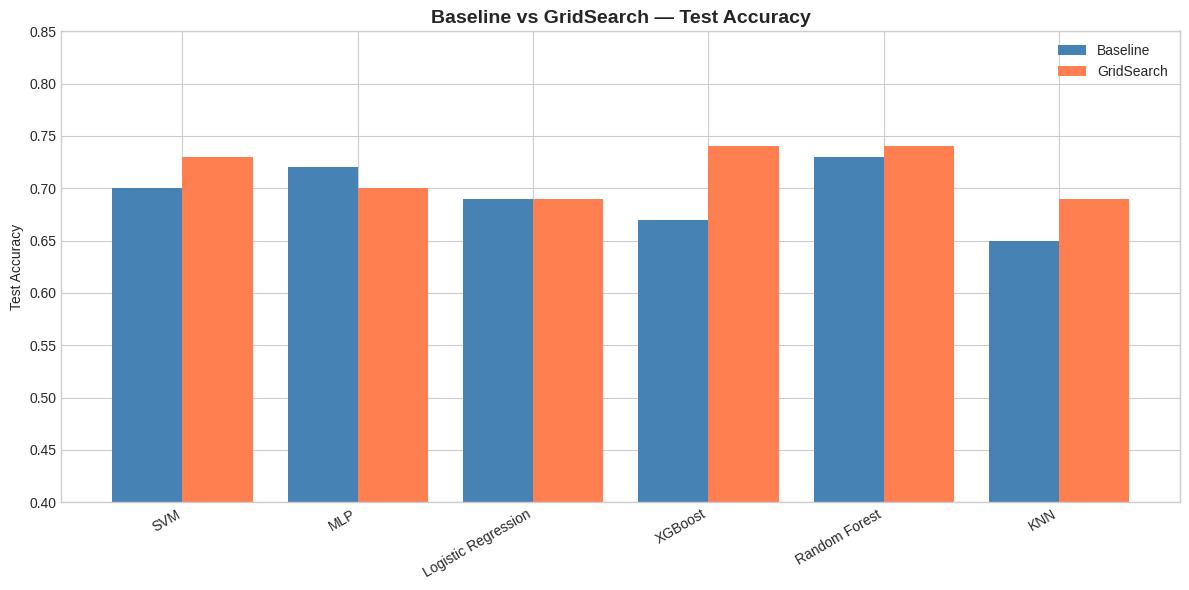

In [94]:
models = comparison["Model"].tolist()
baseline = comparison["Baseline Acc"].tolist()
gridsearch = comparison["GridSearch Acc"].tolist()

plot_baseline_vs_gridsearch(models, baseline, gridsearch)

### 10.3. En İyi Modellerin Karşılaştırmaları

- Buradaki karşılaştırma, modellerin birden fazla parametre setiyle çok kez eğitildiği Grid Search işlemi sonucundaki durumlarının karşılaştırmasıdır.

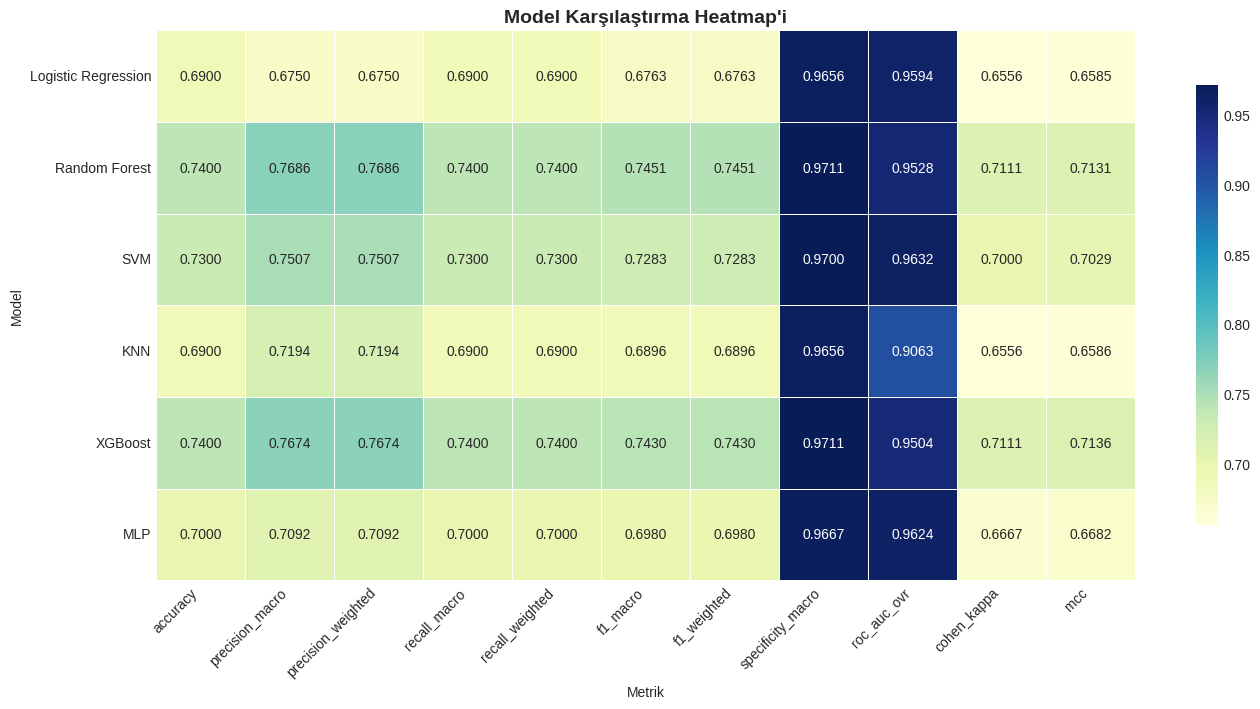

In [95]:
# === GRIDSEARCH EN İYİ MODELLERİN KARŞILAŞTIRMASI ===
all_gs_results = {
    "Logistic Regression": logreg_gs_test_metrics,
    "Random Forest": rf_gs_test_metrics,
    "SVM": svm_gs_test_metrics,
    "KNN": knn_gs_test_metrics,
    "XGBoost": xgb_gs_test_metrics,
    "MLP": mlp_gs_test_metrics,
}

# Heatmap
plot_model_comparison_heatmap(all_gs_results, metric_keys=[
    "accuracy", "precision_macro", "precision_weighted",
    "recall_macro", "recall_weighted", "f1_macro", "f1_weighted",
    "specificity_macro", "roc_auc_ovr", "cohen_kappa", "mcc"
])

### 10.4. ROC Eğrileri

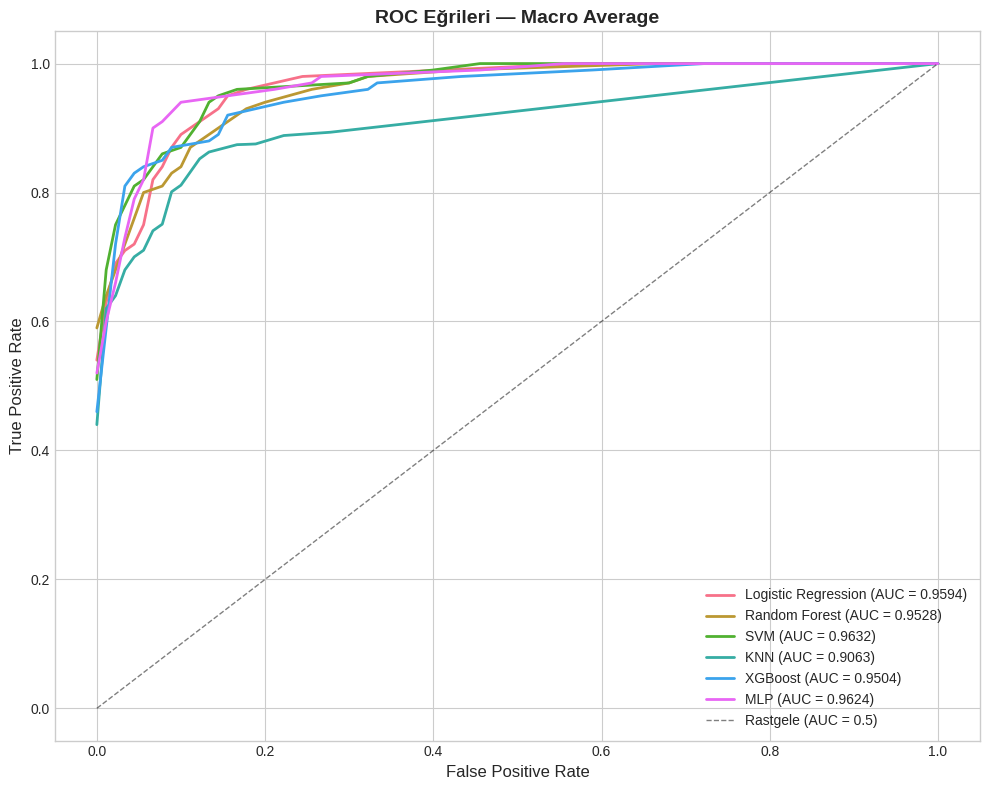

In [96]:
all_gs_models = {
    "Logistic Regression": logreg_best,
    "Random Forest": rf_best,
    "SVM": svm_best,
    "KNN": knn_best,
    "XGBoost": xgb_best,
    "MLP": mlp_best,
}

plot_roc_curves(all_gs_models, X_test_scaled, y_test, le)

10.5. Confusion Matrix

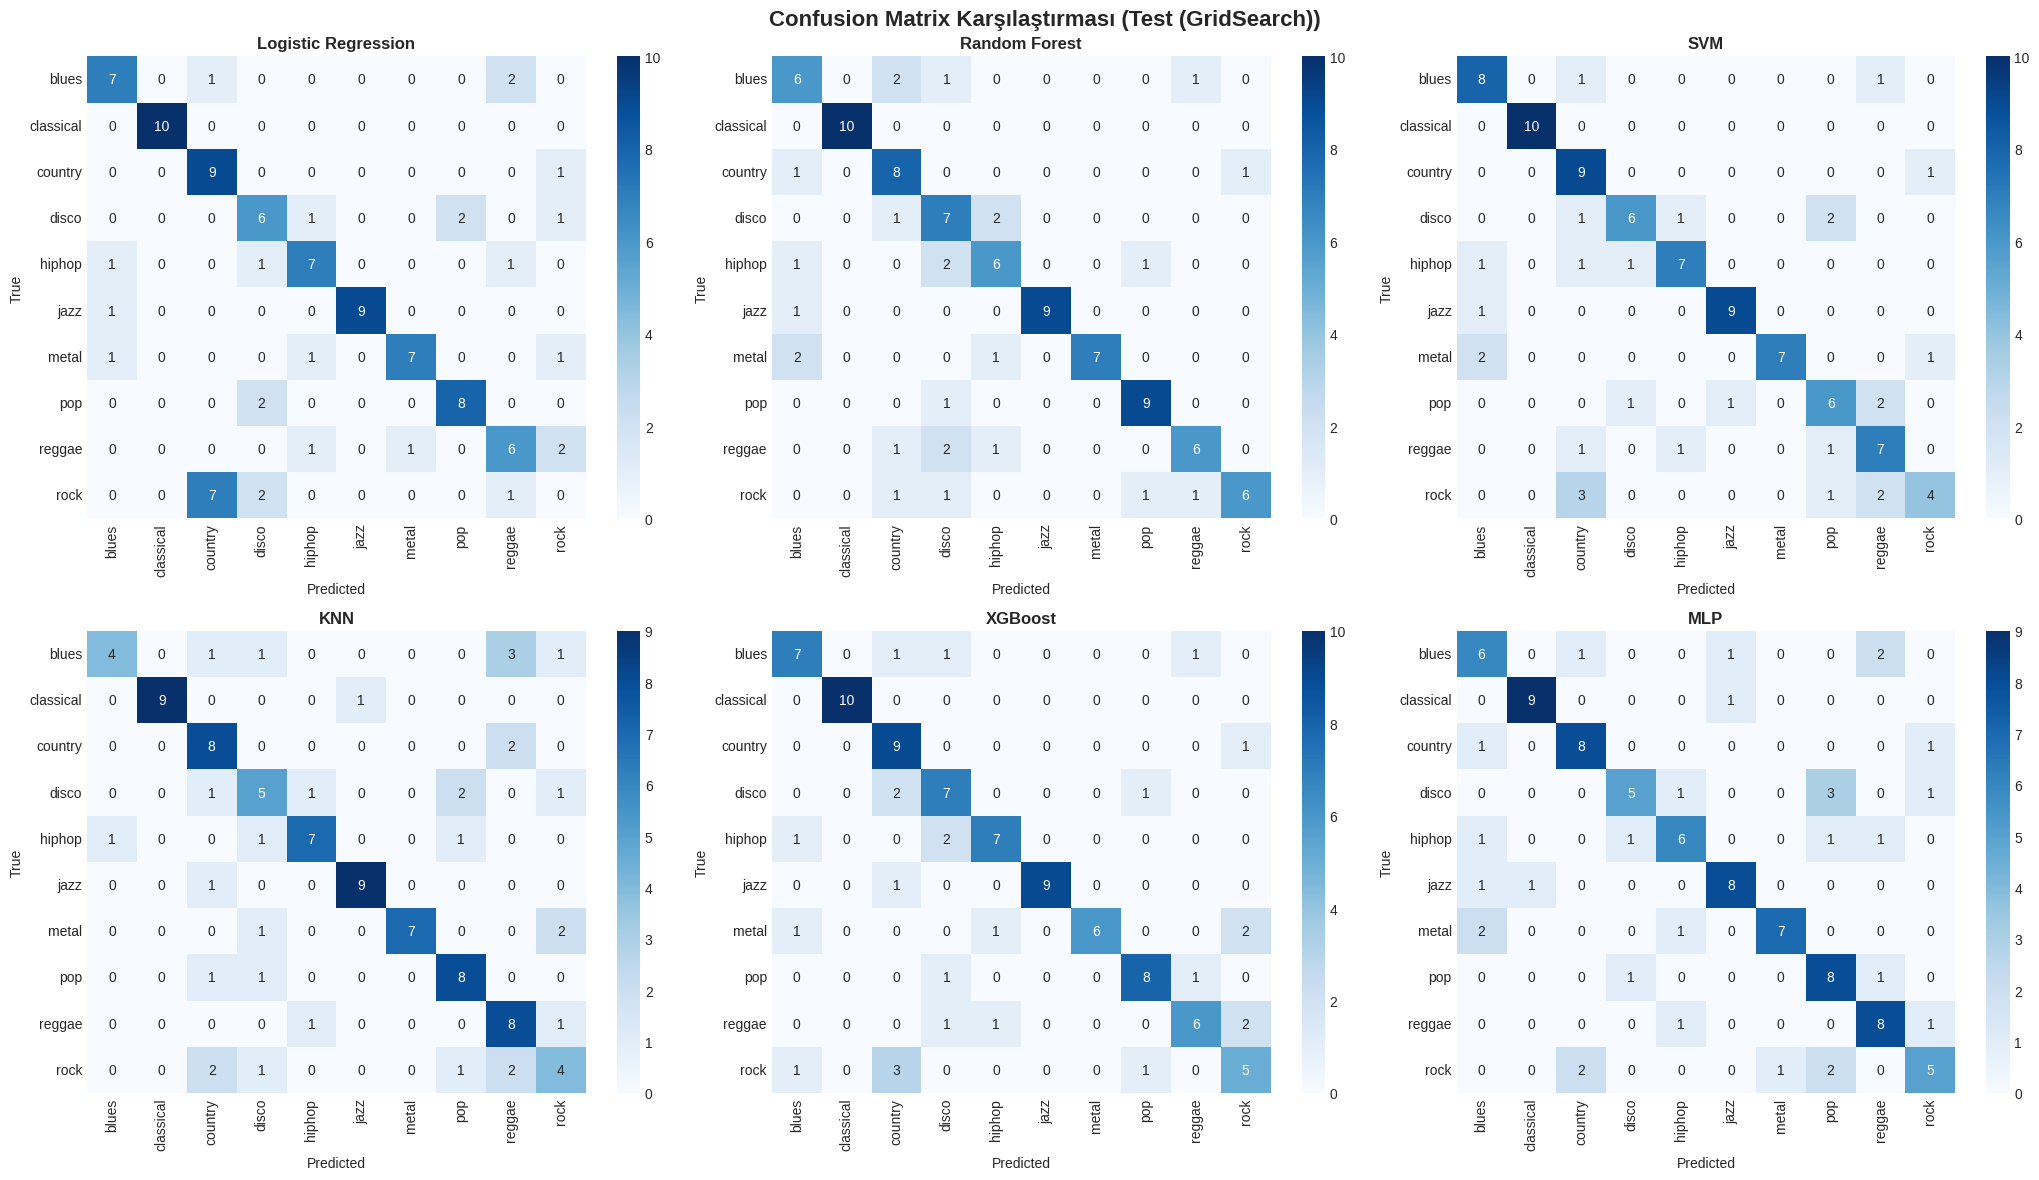

In [97]:
plot_all_confusion_matrices(all_gs_results, le.classes_, "Test (GridSearch)")

### 10.6. Sonuç

In [98]:
# tüm modelleri yazdır
print("=" * 50)
print(" TÜM MODELLER (GridSearch Sonuçları)")
print("=" * 50)

for name, metrics in all_gs_results.items():
    print(f"{name:<20} Acc: {metrics['accuracy']:.2f} | F1: {metrics['f1_macro']:.2f} | ROC: {metrics['roc_auc_ovr']:.2f}")

# en iyi modeli bul
best_model_name, best_metrics = max(
    all_gs_results.items(),
    key=lambda x: x[1]["accuracy"]
)

# en iyi modeli yazdır
print("\n" + "=" * 50)
print(" EN İYİ MODEL")
print("=" * 50)

print(f"Model: {best_model_name}")
print(f" Accuracy: {best_metrics['accuracy']:.2f}")
print(f" F1 (macro): {best_metrics['f1_macro']:.4f}")
print(f" ROC-AUC: {best_metrics['roc_auc_ovr']:.4f}")

 TÜM MODELLER (GridSearch Sonuçları)
Logistic Regression  Acc: 0.69 | F1: 0.68 | ROC: 0.96
Random Forest        Acc: 0.74 | F1: 0.75 | ROC: 0.95
SVM                  Acc: 0.73 | F1: 0.73 | ROC: 0.96
KNN                  Acc: 0.69 | F1: 0.69 | ROC: 0.91
XGBoost              Acc: 0.74 | F1: 0.74 | ROC: 0.95
MLP                  Acc: 0.70 | F1: 0.70 | ROC: 0.96

 EN İYİ MODEL
Model: Random Forest
 Accuracy: 0.74
 F1 (macro): 0.7451
 ROC-AUC: 0.9528


In [99]:
# L.R. -> L.R. için karmaşık dataset -
# R.F. -> veri küçük ve tabular +
# SVM -> karmaşık ayrım +
# KNN -> featurelar çok boyutlu; mesafe mantığı -
# XGBoost -> patternleri iyi yakaladı +
# MLP -> katmanlı yapısından veri boyutu küçük kaldı; performans düştü -